# COHORTE 2 — PARCOURS DATA SCIENCE
# Projet Freestyle — EDA & Data Visualisation
## McDonald's Menu 2026

**Prix, calories et profil nutritionnel**

> Démarche : comprendre → auditer → nettoyer avec justification → explorer → visualiser → interpréter → conclure.


## 1. Introduction et contexte

L'équipe Data Analytics reçoit un jeu de données décrivant un catalogue de produits McDonald's 2026. L'objectif est d'étudier la structure du menu, la qualité des données, les prix, les calories et les caractéristiques nutritionnelles, puis de mettre en évidence les relations descriptives utiles.

**Périmètre :** 1 ligne = 1 produit présent dans le fichier. Il s'agit d'un catalogue, et non d'une base de transactions.


## 2. Problématique

> **Que nous apprennent les données du menu McDonald's 2026 sur la relation entre le prix, les calories et les caractéristiques nutritionnelles des produits ?**


## 3. Objectifs et questions analytiques

### Objectifs
- Comprendre la structure et le contenu du dataset.
- Évaluer la qualité : types, valeurs manquantes, doublons, valeurs suspectes et incohérences.
- Décrire la composition du menu et les catégories.
- Étudier les distributions de prix, calories et nutrition.
- Explorer les relations entre prix, calories et nutrition.
- Identifier les observations atypiques sans les qualifier automatiquement d'erreurs.
- Créer uniquement des indicateurs dérivés justifiés.
- Construire des visualisations qui répondent à des questions précises.
- Formuler une synthèse descriptive sans dépasser ce que les données permettent d'affirmer.

### Questions
| Axe | Question |
|---|---|
| Compréhension | Combien de produits ? Quelles catégories ? |
| Qualité | Quelles valeurs sont manquantes, dupliquées, suspectes ou incohérentes ? |
| Prix | Quelle est la distribution des prix et quelles différences existent entre catégories ? |
| Calories | Comment les calories se distribuent-elles et quelles différences observe-t-on entre catégories ? |
| Nutrition | Comment se répartissent les variables nutritionnelles et quels produits présentent les extrêmes ? |
| Relations | Quelles associations observe-t-on entre prix, calories et nutrition ? |
| Atypiques | Quels produits s'écartent fortement du comportement général ? |
| Visualisation | Quels graphiques répondent le plus clairement aux questions ? |


## 3. Importation des bibliothèques

In [4]:
# ============================================================
# IMPORTATION DES BIBLIOTHÈQUES
# ============================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Style graphique cohérent pour l'ensemble du notebook.
sns.set_theme(style="whitegrid")

# Affichage pandas.
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")


## 5. Chargement du CSV 


In [5]:
# ============================================================
# 5. CHARGEMENT DU DATASET
# ============================================================

from pathlib import Path

# Chemin vers le fichier source
DATA_PATH = Path("../dataset/mcdonalds_menu_csv.csv")

# Vérification de l'existence du fichier
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Le fichier source est introuvable : {DATA_PATH}"
    )

# Chargement du dataset
df = pd.read_csv(DATA_PATH)

# Vérification du chargement
print("=" * 65)
print("CHARGEMENT DU DATASET")
print("=" * 65)

print(f"Source : {DATA_PATH}")
print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")

print("\nAperçu du dataset :")
display(df.head())


CHARGEMENT DU DATASET
Source : ..\dataset\mcdonalds_menu_csv.csv
Dimensions : 80 lignes × 36 colonnes

Aperçu du dataset :


,item_id,item_name,category,description,price_usd,calories,calories_from_fat,total_fat_g,saturated_fat_g,trans_fat_g,cholesterol_mg,sodium_mg,total_carbs_g,dietary_fiber_g,sugars_g,protein_g,calcium_mg,iron_mg,vitamin_a_iu,vitamin_c_mg,is_vegetarian,is_gluten_free,is_dairy_free,is_low_calorie,is_high_protein,is_high_fiber,has_sizes,is_popular,is_limited_time,is_nationwide,serving_size,prep_time_minutes,price_per_calorie,protein_per_dollar,calorie_density,price_history
0,MCD_BURG_Big_Mac_325,Big Mac,Burgers,Signature big mac served hot and fresh,6.55,530,177,27,8.90,1.60,69,924,45,2.60,10.20,26,15,0.30,29,16,False,False,False,False,True,False,False,False,False,True,1 sandwich,2,12.36,3.97,0,"[{""year"": 2023, ""price_usd"": 7.12, ""price_chan..."
1,MCD_BURG_Quarter_Pounder_with_Cheese_180,Quarter Pounder with Cheese,Burgers,Signature quarter pounder with cheese served h...,7.03,515,188,26,8.60,3.80,43,1077,41,2.50,8.80,31,183,2.50,77,8,False,False,False,False,True,False,False,False,False,True,1 sandwich,5,13.65,4.41,0,"[{""year"": 2023, ""price_usd"": 7.42, ""price_chan..."
2,MCD_BURG_Cheeseburger_723,Cheeseburger,Burgers,Delicious cheeseburger from McDonald's,6.81,291,113,13,6.10,1.80,48,695,31,2.40,9.00,16,186,0.50,45,6,False,False,False,False,False,False,False,False,False,True,1 serving,4,23.40,2.35,0,"[{""year"": 2023, ""price_usd"": 7.34, ""price_chan..."
3,MCD_BURG_Double_Cheeseburger_771,Double Cheeseburger,Burgers,Freshly made double cheeseburger,5.84,448,156,23,8.40,2.90,7,1133,36,2.60,3.90,26,161,1.20,8,6,False,False,False,False,True,False,False,False,False,True,1 drink,4,13.04,4.45,0,"[{""year"": 2023, ""price_usd"": 6.34, ""price_chan..."
4,MCD_BURG_McDouble_710,McDouble,Burgers,Signature mcdouble served hot and fresh,5.05,397,86,21,9.40,1.90,74,906,35,3.10,5.80,23,70,1.50,11,24,False,False,False,False,True,False,False,True,False,True,1 drink,9,12.72,4.55,0,"[{""year"": 2023, ""price_usd"": 5.43, ""price_chan..."


## 6. Data Understanding — comprendre le grain et la structure


In [6]:
# ============================================================
# GRAIN DE LA DONNÉE
# ============================================================

# Une ligne représente ici un produit du menu.
grain = "1 ligne = 1 produit du menu"

print("Grain :", grain)
print("Nombre de produits :", len(df))
print("Nombre de colonnes :", df.shape[1])


Grain : 1 ligne = 1 produit du menu
Nombre de produits : 80
Nombre de colonnes : 36


In [7]:
# ============================================================
# INVENTAIRE DES VARIABLES
# ============================================================

inventory = pd.DataFrame({
    "variable": df.columns,
    "type": df.dtypes.astype(str).values,
    "non_null": df.notna().sum().values,
    "missing": df.isna().sum().values,
    "n_unique": df.nunique(dropna=False).values
})

display(inventory)


,variable,type,non_null,missing,n_unique
0,item_id,str,80,0,80
1,item_name,str,80,0,80
2,category,str,80,0,9
3,description,str,80,0,80
4,price_usd,float64,80,0,77
5,calories,int64,80,0,71
6,calories_from_fat,int64,80,0,67
7,total_fat_g,int64,80,0,31
8,saturated_fat_g,float64,80,0,51
9,trans_fat_g,float64,80,0,34


In [8]:
# ============================================================
# TYPES DE VARIABLES
# ============================================================

print("Répartition des types :")
display(df.dtypes.value_counts().rename_axis("type").to_frame("nombre_colonnes"))

print("\nAperçu des premières lignes :")
display(df.head())


Répartition des types :


,nombre_colonnes
type,
int64,12
bool,10
float64,8
str,6



Aperçu des premières lignes :


,item_id,item_name,category,description,price_usd,calories,calories_from_fat,total_fat_g,saturated_fat_g,trans_fat_g,cholesterol_mg,sodium_mg,total_carbs_g,dietary_fiber_g,sugars_g,protein_g,calcium_mg,iron_mg,vitamin_a_iu,vitamin_c_mg,is_vegetarian,is_gluten_free,is_dairy_free,is_low_calorie,is_high_protein,is_high_fiber,has_sizes,is_popular,is_limited_time,is_nationwide,serving_size,prep_time_minutes,price_per_calorie,protein_per_dollar,calorie_density,price_history
0,MCD_BURG_Big_Mac_325,Big Mac,Burgers,Signature big mac served hot and fresh,6.55,530,177,27,8.90,1.60,69,924,45,2.60,10.20,26,15,0.30,29,16,False,False,False,False,True,False,False,False,False,True,1 sandwich,2,12.36,3.97,0,"[{""year"": 2023, ""price_usd"": 7.12, ""price_chan..."
1,MCD_BURG_Quarter_Pounder_with_Cheese_180,Quarter Pounder with Cheese,Burgers,Signature quarter pounder with cheese served h...,7.03,515,188,26,8.60,3.80,43,1077,41,2.50,8.80,31,183,2.50,77,8,False,False,False,False,True,False,False,False,False,True,1 sandwich,5,13.65,4.41,0,"[{""year"": 2023, ""price_usd"": 7.42, ""price_chan..."
2,MCD_BURG_Cheeseburger_723,Cheeseburger,Burgers,Delicious cheeseburger from McDonald's,6.81,291,113,13,6.10,1.80,48,695,31,2.40,9.00,16,186,0.50,45,6,False,False,False,False,False,False,False,False,False,True,1 serving,4,23.40,2.35,0,"[{""year"": 2023, ""price_usd"": 7.34, ""price_chan..."
3,MCD_BURG_Double_Cheeseburger_771,Double Cheeseburger,Burgers,Freshly made double cheeseburger,5.84,448,156,23,8.40,2.90,7,1133,36,2.60,3.90,26,161,1.20,8,6,False,False,False,False,True,False,False,False,False,True,1 drink,4,13.04,4.45,0,"[{""year"": 2023, ""price_usd"": 6.34, ""price_chan..."
4,MCD_BURG_McDouble_710,McDouble,Burgers,Signature mcdouble served hot and fresh,5.05,397,86,21,9.40,1.90,74,906,35,3.10,5.80,23,70,1.50,11,24,False,False,False,False,True,False,False,True,False,True,1 drink,9,12.72,4.55,0,"[{""year"": 2023, ""price_usd"": 5.43, ""price_chan..."


### Lecture métier

Le grain est essentiel : **chaque ligne correspond à un produit**. Les moyennes et comparaisons calculées sur `price_usd`, `calories` ou les variables nutritionnelles décrivent donc les **produits présents dans ce fichier**, et non l'ensemble des ventes de McDonald's.

Les prix observés ne doivent pas non plus être présentés comme des prix universels de McDonald's : ils décrivent uniquement le périmètre du dataset.


## 7. Audit qualité

L'audit est réalisé **avant toute modification**. Les anomalies sont décrites et conservées tant qu'aucune règle fiable ne permet de les corriger.


In [9]:
# ============================================================
# AUDIT 1 — VALEURS MANQUANTES
# ============================================================

missing_audit = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

print("=" * 65)
print("AUDIT — VALEURS MANQUANTES")
print("=" * 65)

if missing_audit["missing_count"].sum() == 0:
    print("✓ Aucune valeur manquante dans le dataset brut.")
else:
    display(missing_audit[missing_audit["missing_count"] > 0])


AUDIT — VALEURS MANQUANTES
✓ Aucune valeur manquante dans le dataset brut.


In [10]:
# ============================================================
# AUDIT 2 — DOUBLONS ET UNICITÉ DE L'IDENTIFIANT
# ============================================================

id_col = "item_id"

full_duplicates = df.duplicated().sum()
id_missing = df[id_col].isna().sum()
id_duplicates = df[id_col].duplicated().sum()
id_unique = df[id_col].nunique()

print("=" * 65)
print("AUDIT — DOUBLONS ET IDENTIFIANT")
print("=" * 65)
print(f"Doublons complets       : {full_duplicates:,}")
print(f"Identifiants uniques    : {id_unique:,}")
print(f"Identifiants manquants  : {id_missing:,}")
print(f"Identifiants dupliqués  : {id_duplicates:,}")


AUDIT — DOUBLONS ET IDENTIFIANT
Doublons complets       : 0
Identifiants uniques    : 80
Identifiants manquants  : 0
Identifiants dupliqués  : 0


In [11]:
# ============================================================
# AUDIT 3 — VALEURS NÉGATIVES
# ============================================================

numeric_cols = df.select_dtypes(include=np.number).columns

negative_audit = (df[numeric_cols] < 0).sum()
negative_audit = negative_audit[negative_audit > 0].sort_values(ascending=False)

print("=" * 65)
print("AUDIT — VALEURS NÉGATIVES")
print("=" * 65)

display(negative_audit.rename("negative_count").to_frame())


AUDIT — VALEURS NÉGATIVES


,negative_count
saturated_fat_g,3
trans_fat_g,3
dietary_fiber_g,1
sugars_g,1


In [12]:
# ============================================================
# AUDIT 4 — INSPECTION DES PRODUITS CONCERNÉS
# ============================================================

negative_cols = [
    "saturated_fat_g",
    "trans_fat_g",
    "dietary_fiber_g",
    "sugars_g"
]

negative_mask = df[negative_cols].lt(0).any(axis=1)

cols_review = [
    "item_id",
    "item_name",
    "category",
    "total_fat_g",
    "saturated_fat_g",
    "trans_fat_g",
    "dietary_fiber_g",
    "sugars_g",
    "total_carbs_g",
    "protein_g",
    "calories"
]

negative_rows = df.loc[negative_mask, cols_review]

print(f"Produits concernés : {len(negative_rows)}")
display(negative_rows)


Produits concernés : 4


,item_id,item_name,category,total_fat_g,saturated_fat_g,trans_fat_g,dietary_fiber_g,sugars_g,total_carbs_g,protein_g,calories
42,MCD_BEVE_Coca-Cola_(Medium)_972,Coca-Cola (Medium),Beverages,0,-0.50,-0.10,5.50,17.80,60,0,220
44,MCD_BEVE_Diet_Coke_(Small)_570,Diet Coke (Small),Beverages,1,0.40,0.10,-0.10,-0.30,0,0,3
49,MCD_BEVE_Iced_Tea_701,Iced Tea,Beverages,0,-0.30,-0.10,0.10,0.30,2,1,4
70,MCD_MCCA_Americano_(Small)_213,Americano (Small),McCafé,0,-0.30,-0.10,0.30,0.40,3,0,7


In [13]:
# ============================================================
# AUDIT 5 — PRIX ET CALORIES
# ============================================================

price_invalid = df["price_usd"] <= 0
calories_invalid = df["calories"] <= 0

print("=" * 65)
print("AUDIT — PRIX ET CALORIES")
print("=" * 65)
print(f"Prix <= 0      : {price_invalid.sum():,}")
print(f"Calories <= 0  : {calories_invalid.sum():,}")


AUDIT — PRIX ET CALORIES
Prix <= 0      : 0
Calories <= 0  : 0


In [14]:
# ============================================================
# AUDIT 6 — CHAÎNES VIDES
# ============================================================

object_cols = df.select_dtypes(include="object").columns

blank_audit = {
    col: df[col].astype(str).str.strip().eq("").sum()
    for col in object_cols
}

blank_audit = pd.Series(blank_audit).sort_values(ascending=False)

print("=" * 65)
print("AUDIT — CHAÎNES VIDES")
print("=" * 65)
display(blank_audit[blank_audit > 0].rename("blank_count").to_frame())
if (blank_audit > 0).sum() == 0:
    print("✓ Aucune chaîne vide détectée.")


AUDIT — CHAÎNES VIDES


C:\Users\Trezkit\AppData\Local\Temp\ipykernel_8288\1335520831.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include="object").columns


,blank_count


✓ Aucune chaîne vide détectée.


In [15]:
# ============================================================
# AUDIT 7 — VARIABLES BOOLÉENNES
# ============================================================

boolean_cols = df.select_dtypes(include="bool").columns

print("=" * 65)
print("AUDIT — VARIABLES BOOLÉENNES")
print("=" * 65)
print(f"Nombre de variables booléennes : {len(boolean_cols)}")
print(list(boolean_cols))


AUDIT — VARIABLES BOOLÉENNES
Nombre de variables booléennes : 10
['is_vegetarian', 'is_gluten_free', 'is_dairy_free', 'is_low_calorie', 'is_high_protein', 'is_high_fiber', 'has_sizes', 'is_popular', 'is_limited_time', 'is_nationwide']


In [17]:
# ============================================================
# AUDIT 9 — COHÉRENCE DES VARIABLES DÉRIVÉES
# ============================================================

# Objectif :
# Vérifier que les variables dérivées présentes dans le dataset
# brut sont cohérentes avec les variables sources utilisées
# pour leur calcul.
#
# Important :
# Cet audit ne crée et ne modifie aucune variable.
# Il vérifie uniquement les variables déjà présentes dans df.


print("=" * 65)
print("AUDIT 9 — COHÉRENCE DES VARIABLES DÉRIVÉES")
print("=" * 65)


# ------------------------------------------------------------
# 1. PROTEIN_PER_DOLLAR
# ------------------------------------------------------------

if "protein_per_dollar" in df.columns:

    expected_protein_per_dollar = (
        df["protein_g"] / df["price_usd"]
    )

    protein_diff = (
        df["protein_per_dollar"]
        - expected_protein_per_dollar
    ).abs()

    print(
        f"Écart maximal protein_per_dollar : "
        f"{protein_diff.max():.6f}"
    )

else:

    print(
        "ℹ️ 'protein_per_dollar' n'existe pas "
        "dans le dataset brut."
    )


# ------------------------------------------------------------
# 2. PRICE_PER_CALORIE
# ------------------------------------------------------------

if "price_per_calorie" in df.columns:

    # La valeur observée dans le dataset correspond à :
    # prix / calories × 1000.
    #
    # Malgré son nom, la variable semble donc représenter
    # un prix normalisé pour 1 000 kcal.

    expected_price_per_calorie = (
        df["price_usd"]
        / df["calories"]
        * 1000
    )

    price_cal_diff = (
        df["price_per_calorie"]
        - expected_price_per_calorie
    ).abs()

    print(
        f"Écart maximal price_per_calorie : "
        f"{price_cal_diff.max():.6f}"
    )

else:

    print(
        "ℹ️ 'price_per_calorie' n'existe pas "
        "dans le dataset brut."
    )


print("-" * 65)
print("CONCLUSION DE L'AUDIT")
print("-" * 65)

print(
    "✓ Les variables dérivées présentes dans le dataset brut "
    "ont été comparées à leurs formules recalculées."
)

if "protein_per_dollar" in df.columns:
    print(
        f"• protein_per_dollar : écart maximal = "
        f"{protein_diff.max():.6f}"
    )

if "price_per_calorie" in df.columns:
    print(
        f"• price_per_calorie : écart maximal = "
        f"{price_cal_diff.max():.6f}"
    )
    print(
        "• Observation : malgré son nom, cette variable "
        "correspond à un prix normalisé pour 1 000 kcal."
    )

print(
    "ℹ️ Aucune variable n'est modifiée pendant cet audit."
)

AUDIT 9 — COHÉRENCE DES VARIABLES DÉRIVÉES
Écart maximal protein_per_dollar : 0.004955
Écart maximal price_per_calorie : 0.004987
-----------------------------------------------------------------
CONCLUSION DE L'AUDIT
-----------------------------------------------------------------
✓ Les variables dérivées présentes dans le dataset brut ont été comparées à leurs formules recalculées.
• protein_per_dollar : écart maximal = 0.004955
• price_per_calorie : écart maximal = 0.004987
• Observation : malgré son nom, cette variable correspond à un prix normalisé pour 1 000 kcal.
ℹ️ Aucune variable n'est modifiée pendant cet audit.


In [18]:
diagnostic_protein = df[
    [
        "item_id",
        "item_name",
        "price_usd",
        "protein_g",
        "protein_per_dollar"
    ]
].copy()

diagnostic_protein["protein_per_dollar_expected"] = (
    diagnostic_protein["protein_g"]
    / diagnostic_protein["price_usd"]
)

diagnostic_protein["difference"] = (
    diagnostic_protein["protein_per_dollar"]
    - diagnostic_protein["protein_per_dollar_expected"]
).abs()

diagnostic_protein = diagnostic_protein.sort_values(
    "difference",
    ascending=False
)

display(diagnostic_protein.head(10))

,item_id,item_name,price_usd,protein_g,protein_per_dollar,protein_per_dollar_expected,difference
29,MCD_SNAC_Chicken_McNuggets_(10_piece)_669,Chicken McNuggets (10 piece),4.44,22,4.95,4.95,0.00
7,MCD_BURG_Quarter_Pounder_with_Cheese_Deluxe_330,Quarter Pounder with Cheese Deluxe,6.63,30,4.52,4.52,0.00
24,MCD_SNAC_French_Fries_(Large)_960,French Fries (Large),3.81,6,1.57,1.57,0.00
60,MCD_DESS_Apple_Pie_863,Apple Pie,3.42,2,0.58,0.58,0.00
66,MCD_MCCA_Cappuccino_(Small)_285,Cappuccino (Small),2.57,6,2.33,2.33,0.00
31,MCD_BREA_Egg_McMuffin_202,Egg McMuffin,6.50,17,2.62,2.62,0.00
54,MCD_DESS_McFlurry_with_Oreo_508,McFlurry with Oreo,4.97,12,2.41,2.41,0.00
4,MCD_BURG_McDouble_710,McDouble,5.05,23,4.55,4.55,0.00
43,MCD_BEVE_Coca-Cola_(Large)_129,Coca-Cola (Large),2.99,1,0.33,0.33,0.00
57,MCD_DESS_Chocolate_Shake_(Small)_838,Chocolate Shake (Small),1.67,12,7.19,7.19,0.00


In [19]:
print("=" * 65)
print("RÉSUMÉ DU DIAGNOSTIC — PROTEIN_PER_DOLLAR")
print("=" * 65)

print(f"Nombre de produits analysés : {len(diagnostic_protein)}")
print(
    f"Écart maximal : "
    f"{diagnostic_protein['difference'].max():.6f}"
)
print(
    f"Écart moyen : "
    f"{diagnostic_protein['difference'].mean():.6f}"
)
print(
    f"Nombre de produits avec écart > 0.01 : "
    f"{(diagnostic_protein['difference'] > 0.01).sum()}"
)

RÉSUMÉ DU DIAGNOSTIC — PROTEIN_PER_DOLLAR
Nombre de produits analysés : 80
Écart maximal : 0.004955
Écart moyen : 0.002142
Nombre de produits avec écart > 0.01 : 0


In [20]:
# ============================================================
# AUDIT 10 — CALORIE_DENSITY
# ============================================================

calorie_density_unique = df["calorie_density"].nunique(dropna=False)
calorie_density_zero = (df["calorie_density"] == 0).sum()

print("=" * 65)
print("AUDIT — CALORIE_DENSITY")
print("=" * 65)
print(f"Valeurs distinctes : {calorie_density_unique}")
print(f"Valeurs égales à 0 : {calorie_density_zero:,}/{len(df):,}")

if calorie_density_zero == len(df):
    print("⚠ Variable non discriminante dans le fichier : elle vaut 0 pour tous les produits.")


AUDIT — CALORIE_DENSITY
Valeurs distinctes : 1
Valeurs égales à 0 : 80/80
⚠ Variable non discriminante dans le fichier : elle vaut 0 pour tous les produits.


In [21]:
# ============================================================
# AUDIT 11 — COHÉRENCE DE CALORIES_FROM_FAT
# ============================================================

# Objectif :
# Comparer calories_from_fat à une estimation théorique
# basée sur 9 kcal par gramme de lipides.
#
# IMPORTANT :
# Il s'agit d'un contrôle indicatif et non d'une règle
# de correction automatique.
#
# Un écart important ne signifie pas nécessairement que
# calories_from_fat est erronée.

fat_cal_expected = df["total_fat_g"] * 9

fat_cal_diff = (
    df["calories_from_fat"] - fat_cal_expected
).abs()

print("=" * 65)
print("AUDIT 11 — COHÉRENCE DE CALORIES_FROM_FAT")
print("=" * 65)

print(
    f"Écart maximal avec 9 × total_fat_g : "
    f"{fat_cal_diff.max():.2f} kcal"
)

print(
    f"Écart moyen : "
    f"{fat_cal_diff.mean():.2f} kcal"
)

print(
    f"Produits avec écart > 20 kcal : "
    f"{(fat_cal_diff > 20).sum():,}"
)

print(
    f"Proportion concernée : "
    f"{(fat_cal_diff > 20).mean() * 100:.1f}%"
)

print("\nProduits présentant les écarts les plus importants :")

diagnostic_fat = df[
    [
        "item_name",
        "total_fat_g",
        "calories_from_fat",
        "calories"
    ]
].copy()

diagnostic_fat["calories_from_fat_expected"] = (
    diagnostic_fat["total_fat_g"] * 9
)

diagnostic_fat["difference"] = (
    diagnostic_fat["calories_from_fat"]
    - diagnostic_fat["calories_from_fat_expected"]
).abs()

diagnostic_fat = diagnostic_fat.sort_values(
    "difference",
    ascending=False
)

display(diagnostic_fat.head(10))

print("\nConclusion :")
print(
    "Le contrôle met en évidence des écarts importants entre "
    "calories_from_fat et l'estimation théorique 9 × lipides."
)
print(
    "Ces écarts constituent un signal de contrôle, mais ne "
    "permettent pas à eux seuls de conclure à une erreur des données."
)
print(
    "Aucune valeur n'est modifiée pendant cet audit."
)

AUDIT 11 — COHÉRENCE DE CALORIES_FROM_FAT
Écart maximal avec 9 × total_fat_g : 237.00 kcal
Écart moyen : 42.96 kcal
Produits avec écart > 20 kcal : 54
Proportion concernée : 67.5%

Produits présentant les écarts les plus importants :


,item_name,total_fat_g,calories_from_fat,calories,calories_from_fat_expected,difference
40,Deluxe Breakfast,44,159,654,396,237
36,Sausage Biscuit with Egg,35,115,546,315,200
35,Sausage Biscuit,30,108,457,270,162
7,Quarter Pounder with Cheese Deluxe,31,126,577,279,153
29,Chicken McNuggets (10 piece),24,83,412,216,133
34,"Bacon, Egg & Cheese Biscuit",27,126,469,243,117
4,McDouble,21,86,397,189,103
11,Filet-O-Fish,20,91,386,180,89
42,Coca-Cola (Medium),0,88,220,0,88
41,Coca-Cola (Small),0,76,157,0,76



Conclusion :
Le contrôle met en évidence des écarts importants entre calories_from_fat et l'estimation théorique 9 × lipides.
Ces écarts constituent un signal de contrôle, mais ne permettent pas à eux seuls de conclure à une erreur des données.
Aucune valeur n'est modifiée pendant cet audit.


In [22]:
# ============================================================
# AUDIT — PRICE_HISTORY : structure, années et cohérence 2026
# ============================================================
def parse_price_history(value):
    try:
        parsed = json.loads(value) if isinstance(value, str) else value
    except (TypeError, json.JSONDecodeError):
        return None
    return parsed if isinstance(parsed, list) else None

def audit_history(value, current_price):
    h = parse_price_history(value)
    result = {"valid_structure": False, "chronological": False, "has_2026": False, "price_matches_2026": False, "pct_changes_consistent": False}
    if not h: return result
    keys = {"year", "price_usd", "price_change_percent"}
    result["valid_structure"] = all(isinstance(x, dict) and keys.issubset(x) for x in h)
    if not result["valid_structure"]: return result
    years = [x["year"] for x in h]
    result["chronological"] = years == sorted(years) and len(years) == len(set(years))
    y26 = next((x for x in h if x["year"] == 2026), None)
    result["has_2026"] = y26 is not None
    if y26 is not None: result["price_matches_2026"] = bool(np.isclose(float(current_price), float(y26["price_usd"]), atol=0.01))
    checks=[]
    for prev, cur in zip(h, h[1:]):
        try:
            expected=(float(cur["price_usd"])-float(prev["price_usd"]))/float(prev["price_usd"])*100
            checks.append(np.isclose(float(cur["price_change_percent"]), expected, atol=0.15))
        except (TypeError,ValueError,ZeroDivisionError): checks.append(False)
    result["pct_changes_consistent"] = all(checks) if checks else True
    return result

history_rows=[]
for _, row in df.iterrows():
    history_rows.append({"item_id":row["item_id"], **audit_history(row["price_history"],row["price_usd"])})
history_audit=pd.DataFrame(history_rows)
display(history_audit)
print(f"Structures valides : {history_audit['valid_structure'].sum():,}/{len(history_audit):,}")
print(f"Prix 2026 cohérent avec price_usd : {history_audit['price_matches_2026'].sum():,}/{len(history_audit):,}")


,item_id,valid_structure,chronological,has_2026,price_matches_2026,pct_changes_consistent
0,MCD_BURG_Big_Mac_325,True,True,True,True,False
1,MCD_BURG_Quarter_Pounder_with_Cheese_180,True,True,True,True,False
2,MCD_BURG_Cheeseburger_723,True,True,True,True,False
3,MCD_BURG_Double_Cheeseburger_771,True,True,True,True,False
4,MCD_BURG_McDouble_710,True,True,True,True,False
...,...,...,...,...,...,...
75,MCD_MCCA_Mocha_Frappé_(Small)_246,True,True,True,True,False
76,MCD_HAPP_Happy_Meal_Cheeseburger_355,True,True,True,True,False
77,MCD_HAPP_Happy_Meal_Chicken_McNuggets_(4_piece...,True,True,True,True,False
78,MCD_HAPP_Happy_Meal_Hamburger_578,True,True,True,True,False


Structures valides : 80/80
Prix 2026 cohérent avec price_usd : 80/80


### Synthèse de l'audit

La qualité est évaluée sur la complétude, l'unicité, la plausibilité des valeurs et la cohérence entre variables liées. Une anomalie n'est pas automatiquement supprimée ou corrigée.


## 8. Nettoyage et justification des traitements


**Règle :** conserver `df` comme source brute et appliquer uniquement des transformations explicitement justifiées par les audits qualité. Les valeurs négatives identifiées dans les variables nutritionnelles `saturated_fat_g`, `trans_fat_g`, `dietary_fiber_g` et `sugars_g` sont considérées comme incohérentes avec la nature de ces mesures. La décision retenue consiste à remplacer ces valeurs par leur valeur absolue.

Afin de garantir la traçabilité, les données originales sont conservées dans `df_raw`. La variable `is_changed_value_absolute` permet d'identifier les produits concernés par cette correction, tandis que des indicateurs spécifiques permettent d'identifier les variables effectivement modifiées.

Les valeurs manquantes réellement présentes dans les données sources sont conservées comme `NaN` et ne sont pas remplacées arbitrairement par zéro, une moyenne ou une médiane.

Cette correction constitue une **règle de nettoyage documentée** fondée sur les résultats de l'audit. Elle ne doit pas être interprétée comme une modification de la source brute : les valeurs originales restent accessibles dans `df_raw`.



In [23]:

# ============================================================
# 8. DATA CLEANING — NETTOYAGE FINAL ET TRAÇABLE
# ============================================================

# Principe :
# - conserver df comme source brute ;
# - appliquer uniquement des transformations justifiées ;
# - conserver les valeurs originales dans df_raw ;
# - corriger les valeurs négatives nutritionnelles identifiées
#   selon la règle de valeur absolue retenue ;
# - ajouter des indicateurs permettant de tracer les corrections ;
# - conserver les valeurs réellement manquantes comme NaN ;
# - ne pas supprimer une ligne uniquement parce qu'elle contient
#   une anomalie sur une variable.


df_raw = df.copy()
df_clean = df_raw.copy()

print("=" * 70)
print("DATA CLEANING — NETTOYAGE DES DONNÉES")
print("=" * 70)


# ------------------------------------------------------------
# 1. STANDARDISATION DES VARIABLES TEXTUELLES
# ------------------------------------------------------------

string_cols = [
    "item_id",
    "item_name",
    "category",
    "description",
    "serving_size"
]

for col in string_cols:
    if col in df_clean.columns:
        df_clean[col] = (
            df_clean[col]
            .astype("string")
            .str.strip()
        )


# ------------------------------------------------------------
# 2. CONVERSION DES VARIABLES NUMÉRIQUES
# ------------------------------------------------------------

numeric_cols = [
    "price_usd",
    "calories",
    "calories_from_fat",
    "total_fat_g",
    "saturated_fat_g",
    "trans_fat_g",
    "cholesterol_mg",
    "sodium_mg",
    "total_carbs_g",
    "dietary_fiber_g",
    "sugars_g",
    "protein_g",
    "calcium_mg",
    "iron_mg",
    "vitamin_a_iu",
    "vitamin_c_mg",
    "prep_time_minutes"
]

for col in numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(
            df_clean[col],
            errors="coerce"
        )


# ------------------------------------------------------------
# 3. IDENTIFICATION DES VALEURS NÉGATIVES
# ------------------------------------------------------------

nutrition_cols = [
    "total_fat_g",
    "saturated_fat_g",
    "trans_fat_g",
    "cholesterol_mg",
    "sodium_mg",
    "total_carbs_g",
    "dietary_fiber_g",
    "sugars_g",
    "protein_g",
    "calcium_mg",
    "iron_mg",
    "vitamin_a_iu",
    "vitamin_c_mg"
]

# Les valeurs négatives sont recherchées dans toutes les
# variables numériques pour permettre un audit complet.

negative_cols = [
    col for col in numeric_cols
    if col in df_clean.columns
]

negative_counts = {
    col: int((df_clean[col] < 0).sum())
    for col in negative_cols
}

negative_summary = pd.Series(
    negative_counts,
    name="nb_negatives"
)

negative_summary = (
    negative_summary[
        negative_summary > 0
    ]
    .sort_values(ascending=False)
    .to_frame()
)

print("\nValeurs négatives détectées :")

if negative_summary.empty:
    print("Aucune valeur négative détectée.")
else:
    display(negative_summary)


# ------------------------------------------------------------
# 4. DÉFINITION DES VARIABLES CONCERNÉES PAR LA CORRECTION
# ------------------------------------------------------------

# Après audit, les valeurs négatives observées concernent
# des variables nutritionnelles exprimées en grammes.
#
# Pour ces variables, une valeur négative est incohérente
# avec la nature physique de la mesure.
#
# La règle retenue est :
#
#        valeur négative → valeur absolue
#
# Cette décision constitue une règle de nettoyage documentée.
#
# IMPORTANT :
# Les valeurs originales restent disponibles dans df_raw.

absolute_correction_cols = [
    "saturated_fat_g",
    "trans_fat_g",
    "dietary_fiber_g",
    "sugars_g"
]

absolute_correction_cols = [
    col for col in absolute_correction_cols
    if col in df_clean.columns
]


# ------------------------------------------------------------
# 5. CRÉATION DES FLAGS DE TRAÇABILITÉ
# ------------------------------------------------------------

# Flag global :
# True = au moins une valeur a été corrigée par valeur absolue
# pour ce produit.

df_clean["is_changed_value_absolute"] = False


# Création d'un flag spécifique pour chaque variable.

for col in absolute_correction_cols:

    flag_col = f"{col}_changed_absolute"

    df_clean[flag_col] = (
        df_clean[col] < 0
    )


# ------------------------------------------------------------
# 6. APPLICATION DE LA CORRECTION PAR VALEUR ABSOLUE
# ------------------------------------------------------------

for col in absolute_correction_cols:

    mask = df_clean[col] < 0

    df_clean.loc[mask, col] = (
        df_clean.loc[mask, col].abs()
    )


# Mise à jour du flag global après identification des
# variables réellement modifiées.

flag_cols = [
    f"{col}_changed_absolute"
    for col in absolute_correction_cols
]

df_clean["is_changed_value_absolute"] = (
    df_clean[flag_cols]
    .any(axis=1)
)


# ------------------------------------------------------------
# 7. CONTRÔLE DES CORRECTIONS EFFECTUÉES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CONTRÔLE DES CORRECTIONS PAR VALEUR ABSOLUE")
print("=" * 70)

nb_products_changed = int(
    df_clean["is_changed_value_absolute"].sum()
)

print(
    f"Produits concernés par une correction : "
    f"{nb_products_changed}"
)

if nb_products_changed > 0:

    display(
        df_clean.loc[
            df_clean["is_changed_value_absolute"],
            [
                "item_id",
                "item_name",
                "category"
            ] + flag_cols
        ]
    )

else:
    print("Aucune correction par valeur absolue effectuée.")


# ------------------------------------------------------------
# 8. DOUBLONS EXACTS
# ------------------------------------------------------------

duplicate_count = df_clean.duplicated().sum()

print("\nDoublons exacts détectés :", duplicate_count)

if duplicate_count > 0:

    df_clean = (
        df_clean
        .drop_duplicates()
        .copy()
    )

    print(
        f"{duplicate_count} doublon(s) exact(s) supprimé(s)."
    )

else:

    print("Aucun doublon exact supprimé.")


# ------------------------------------------------------------
# 9. CONTRÔLE DE L'UNICITÉ DE item_id
# ------------------------------------------------------------

if "item_id" in df_clean.columns:

    duplicated_ids = (
        df_clean["item_id"]
        .duplicated(keep=False)
    )

    nb_duplicate_ids = int(
        duplicated_ids.sum()
    )

    print(
        "\nProduits concernés par un item_id dupliqué :",
        nb_duplicate_ids
    )

    if nb_duplicate_ids > 0:

        print(
            "⚠️ Les doublons d'identifiant ne sont pas "
            "supprimés automatiquement."
        )

        print(
            "Ils doivent être analysés avant toute suppression."
        )

    else:

        print("Aucun item_id dupliqué détecté.")


# ------------------------------------------------------------
# 10. CRÉATION DE LA TABLE D'ANALYSE
# ------------------------------------------------------------

# df_analysis correspond à la version utilisée pour les analyses.
#
# Les valeurs négatives identifiées ont déjà été corrigées
# dans df_clean selon la règle documentée.
#
# Les valeurs réellement manquantes présentes dans la source
# restent des NaN.

df_analysis = df_clean.copy()


# ------------------------------------------------------------
# 11. CONTRÔLE FINAL
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CONTRÔLE FINAL DU NETTOYAGE")
print("=" * 70)

print(
    f"Dataset brut      : "
    f"{df_raw.shape[0]} lignes × {df_raw.shape[1]} colonnes"
)

print(
    f"Dataset nettoyé   : "
    f"{df_clean.shape[0]} lignes × {df_clean.shape[1]} colonnes"
)

print(
    f"Dataset analyse   : "
    f"{df_analysis.shape[0]} lignes × {df_analysis.shape[1]} colonnes"
)

print(
    "\nNombre total de valeurs manquantes après nettoyage :",
    int(df_clean.isna().sum().sum())
)

print(
    "Nombre de produits corrigés par valeur absolue :",
    int(df_clean["is_changed_value_absolute"].sum())
)

print("\nNettoyage terminé.")



DATA CLEANING — NETTOYAGE DES DONNÉES

Valeurs négatives détectées :


,nb_negatives
saturated_fat_g,3
trans_fat_g,3
dietary_fiber_g,1
sugars_g,1



CONTRÔLE DES CORRECTIONS PAR VALEUR ABSOLUE
Produits concernés par une correction : 4


,item_id,item_name,category,saturated_fat_g_changed_absolute,trans_fat_g_changed_absolute,dietary_fiber_g_changed_absolute,sugars_g_changed_absolute
42,MCD_BEVE_Coca-Cola_(Medium)_972,Coca-Cola (Medium),Beverages,True,True,False,False
44,MCD_BEVE_Diet_Coke_(Small)_570,Diet Coke (Small),Beverages,False,False,True,True
49,MCD_BEVE_Iced_Tea_701,Iced Tea,Beverages,True,True,False,False
70,MCD_MCCA_Americano_(Small)_213,Americano (Small),McCafé,True,True,False,False



Doublons exacts détectés : 0
Aucun doublon exact supprimé.

Produits concernés par un item_id dupliqué : 0
Aucun item_id dupliqué détecté.

CONTRÔLE FINAL DU NETTOYAGE
Dataset brut      : 80 lignes × 36 colonnes
Dataset nettoyé   : 80 lignes × 41 colonnes
Dataset analyse   : 80 lignes × 41 colonnes

Nombre total de valeurs manquantes après nettoyage : 0
Nombre de produits corrigés par valeur absolue : 4

Nettoyage terminé.


### Décisions non appliquées automatiquement

**`calorie_density` :** la variable présente dans le dataset vaut 0 pour tous les produits. Cette situation a été identifiée lors de l'audit qualité. Aucune valeur de remplacement n'est générée automatiquement, car le dataset ne fournit pas suffisamment d'éléments pour déterminer avec certitude la définition exacte de cette variable et reconstruire une valeur fiable. La variable est donc conservée telle quelle et ne sera pas utilisée comme indicateur analytique principal.

**`calories_from_fat` :** le contrôle indicatif basé sur la relation théorique `total_fat_g × 9` met en évidence des écarts importants pour plusieurs produits. Ces écarts ne suffisent cependant pas à démontrer que les valeurs sources sont erronées. Aucune correction automatique n'est donc appliquée. La variable est conservée dans le dataset afin de préserver l'information source, mais son utilisation sera limitée dans l'interprétation et elle ne servira pas à établir une conclusion forte sur la composition calorique des produits.

**Principe général :** lorsqu'un audit révèle une incohérence mais que la donnée correcte ne peut pas être déterminée de manière fiable à partir des informations disponibles, aucune valeur n'est inventée. La donnée est conservée, l'anomalie est documentée et son utilisation analytique est limitée lorsque cela est nécessaire.



## 9. Feature Engineering

Les variables dérivées sont créées uniquement lorsqu'elles répondent directement à une question analytique du projet. Chaque variable est calculée à partir de variables existantes selon une formule explicite et documentée.

Les indicateurs créés sont descriptifs et comparatifs. Ils ne représentent ni des données commerciales réelles, ni des recommandations nutritionnelles. Le dataset étant un catalogue de produits et non une base de transactions, les ratios liés au prix ne peuvent pas être interprétés comme une mesure réelle de rentabilité, de performance commerciale ou de « meilleur rapport qualité-prix ».

Les variables dérivées sont calculées à partir de df_analysis, c'est-à-dire de la version du dataset destinée aux analyses après application des règles de nettoyage documentées.


### 9.1 Prix normalisé pour 1 000 kcal

Question analytique :
Quel est le prix d'un produit rapporté à une quantité standard de 1 000 kcal ?

In [24]:
# ============================================================
# 9.1 PRIX POUR 1 000 KCAL
# ============================================================

df_analysis["price_per_1000_kcal"] = np.where(
    df_analysis["calories"] > 0,
    df_analysis["price_usd"]
    / df_analysis["calories"]
    * 1000,
    np.nan
)

print("Variable créée : price_per_1000_kcal")

display(
    df_analysis[
        ["item_name", "price_usd", "calories", "price_per_1000_kcal"]
    ].head()
)



Variable créée : price_per_1000_kcal


,item_name,price_usd,calories,price_per_1000_kcal
0,Big Mac,6.55,530,12.36
1,Quarter Pounder with Cheese,7.03,515,13.65
2,Cheeseburger,6.81,291,23.40
3,Double Cheeseburger,5.84,448,13.04
4,McDouble,5.05,397,12.72


Interprétation :

Cette variable permet de comparer les prix des produits sur une base calorique commune.

Limite :

Il s'agit d'un ratio descriptif. Un prix plus faible pour 1 000 kcal ne signifie pas qu'un produit présente une meilleure valeur commerciale, nutritionnelle ou alimentaire.

9.2 Calories par dollar

Question analytique :
Combien de calories sont disponibles pour chaque dollar dépensé ?

In [25]:
# ============================================================
# 9.2 CALORIES PAR DOLLAR
# ============================================================

df_analysis["calories_per_dollar"] = np.where(
    df_analysis["price_usd"] > 0,
    df_analysis["calories"]
    / df_analysis["price_usd"],
    np.nan
)

print("Variable créée : calories_per_dollar")

display(
    df_analysis[
        ["item_name", "price_usd", "calories", "calories_per_dollar"]
    ].head()
)

Variable créée : calories_per_dollar


,item_name,price_usd,calories,calories_per_dollar
0,Big Mac,6.55,530,80.92
1,Quarter Pounder with Cheese,7.03,515,73.26
2,Cheeseburger,6.81,291,42.73
3,Double Cheeseburger,5.84,448,76.71
4,McDouble,5.05,397,78.61


Interprétation :

Cet indicateur permet de comparer la quantité de calories rapportée au prix du produit.

Limite :

Il s'agit uniquement d'un ratio mathématique. Il ne constitue pas une mesure de « valeur » au sens commercial ou nutritionnel.

9.3 Protéines par dollar

Question analytique :
Quelle quantité de protéines est associée à chaque dollar du prix du produit

In [26]:
# ============================================================
# 9.3 PROTÉINES PAR DOLLAR
# ============================================================


df_analysis["protein_per_dollar"] = np.where(
    df_analysis["price_usd"] > 0,
    df_analysis["protein_g"]
    / df_analysis["price_usd"],
    np.nan
)

print("Variable créée : protein_per_dollar")

display(
    df_analysis[
        ["item_name", "price_usd", "protein_g", "protein_per_dollar"]
    ].head()
)

Variable créée : protein_per_dollar


,item_name,price_usd,protein_g,protein_per_dollar
0,Big Mac,6.55,26,3.97
1,Quarter Pounder with Cheese,7.03,31,4.41
2,Cheeseburger,6.81,16,2.35
3,Double Cheeseburger,5.84,26,4.45
4,McDouble,5.05,23,4.55


9.4 Catégorie de prix

Question analytique :
Comment les produits se répartissent-ils selon leur niveau de prix relatif dans le dataset ?

Pour éviter de présenter des seuils arbitraires comme des seuils universels, la segmentation est construite à partir des quartiles observés dans l'échantillon.

In [27]:
# ============================================================
# 9.4 CATÉGORIE DE PRIX
# ============================================================

q1 = df_analysis["price_usd"].quantile(0.25)
q2 = df_analysis["price_usd"].quantile(0.50)
q3 = df_analysis["price_usd"].quantile(0.75)

df_analysis["price_category"] = pd.cut(
    df_analysis["price_usd"],
    bins=[
        -np.inf,
        q1,
        q2,
        q3,
        np.inf
    ],
    labels=[
        "Q1",
        "Q2",
        "Q3",
        "Q4"
    ],
    include_lowest=True
)

print("Seuils de segmentation :")
print(f"Q1 : {q1:.2f} USD")
print(f"Q2 : {q2:.2f} USD")
print(f"Q3 : {q3:.2f} USD")

display(
    df_analysis[
        ["item_name", "price_usd", "price_category"]
    ].head()
)

Seuils de segmentation :
Q1 : 2.62 USD
Q2 : 3.98 USD
Q3 : 5.32 USD


,item_name,price_usd,price_category
0,Big Mac,6.55,Q4
1,Quarter Pounder with Cheese,7.03,Q4
2,Cheeseburger,6.81,Q4
3,Double Cheeseburger,5.84,Q4
4,McDouble,5.05,Q3


Interprétation :

Cette variable permet de comparer les produits selon leur position relative dans la distribution des prix du dataset.

Limite :

Q1, Q2, Q3 et Q4 sont des catégories relatives à cet échantillon. Elles ne signifient pas respectivement « économique », « standard » ou « premium » à l'échelle de McDonald's ou du marché.

### 9.5 Vérification des variables dérivées

Après leur création, les variables dérivées sont contrôlées afin de vérifier qu'elles ne génèrent pas de valeurs incohérentes.

In [28]:
# ============================================================
# 9.5 CONTRÔLE DES VARIABLES DÉRIVÉES
# ============================================================

derived_cols = [
    "price_per_1000_kcal",
    "calories_per_dollar",
    "protein_per_dollar"
]

print("=" * 70)
print("CONTRÔLE DES VARIABLES DÉRIVÉES")
print("=" * 70)

for col in derived_cols:
    print(
        f"{col} : "
        f"{df_analysis[col].notna().sum()} valeurs calculées, "
        f"{df_analysis[col].isna().sum()} valeurs manquantes"
    )

print("\nRésumé statistique :")

display(
    df_analysis[derived_cols].describe().T
)


CONTRÔLE DES VARIABLES DÉRIVÉES
price_per_1000_kcal : 80 valeurs calculées, 0 valeurs manquantes
calories_per_dollar : 80 valeurs calculées, 0 valeurs manquantes
protein_per_dollar : 80 valeurs calculées, 0 valeurs manquantes

Résumé statistique :


,count,mean,std,min,25%,50%,75%,max
price_per_1000_kcal,80.00,40.98,114.61,3.01,10.61,13.62,19.76,712.50
calories_per_dollar,80.00,84.74,64.27,1.40,50.60,73.44,94.21,332.70
protein_per_dollar,80.00,2.69,2.04,0.00,1.14,2.52,3.98,10.98


### Synthèse du Feature Engineering

Les variables créées répondent donc à quatre besoins analytiques :

Variable	Question	Type
price_per_1000_kcal	Quel est le prix rapporté à 1 000 kcal ?	Ratio
calories_per_dollar	Combien de calories par dollar ?	Ratio
protein_per_dollar	Combien de grammes de protéines par dollar ?	Ratio
price_category	Quelle est la position relative du prix ?	Catégorielle

Ces variables ne modifient pas les données sources. Elles sont créées séparément dans df_analysis afin de conserver une distinction claire entre les données originales, les données nettoyées et les variables construites pour l'analyse.

Principe d'interprétation : ces indicateurs permettent de comparer les produits entre eux dans le périmètre du dataset. Ils ne permettent pas de conclure sur les ventes, la rentabilité, la qualité nutritionnelle globale ou la performance commerciale réelle des produits.

## 10. EDA univariée — composition, prix, calories et nutrition


In [29]:
# ============================================================
# 10.1 PRODUITS PAR CATÉGORIE
# ============================================================

category_counts = (
    df_analysis["category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="n_products")
)

category_counts["share_pct"] = (
    category_counts["n_products"]
    / len(df_analysis)
    * 100
).round(1)

display(category_counts)


,category,n_products,share_pct
0,Beverages,12,15.00
1,McCafé,12,15.00
2,Desserts,11,13.80
3,Burgers,10,12.50
4,Breakfast,10,12.50
5,Snacks & Sides,9,11.20
6,Chicken & Sandwiches,7,8.80
7,Salads,5,6.20
8,Happy Meal,4,5.00


In [30]:
# ============================================================
# 10.2 DISTRIBUTION DES PRIX
# ============================================================

price_stats = df_analysis["price_usd"].describe()

price_summary = pd.Series({
    "min": df_analysis["price_usd"].min(),
    "max": df_analysis["price_usd"].max(),
    "mean": df_analysis["price_usd"].mean(),
    "median": df_analysis["price_usd"].median(),
    "std": df_analysis["price_usd"].std(),
    "q1": df_analysis["price_usd"].quantile(0.25),
    "q3": df_analysis["price_usd"].quantile(0.75)
}).round(2)

display(price_summary.to_frame("price_usd"))

,price_usd
min,1.19
max,7.70
mean,4.08
median,3.98
std,1.72
q1,2.62
q3,5.32


In [31]:
# ============================================================
# 10.3 PRIX PAR CATÉGORIE
# ============================================================

price_by_category = (
    df_analysis
    .groupby("category")["price_usd"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("median", ascending=False)
    .round(2)
)

display(price_by_category)

,count,mean,median,std,min,max
category,,,,,,
Burgers,10,5.88,5.98,0.90,4.37,7.03
Salads,5,5.76,5.82,0.41,5.21,6.32
Happy Meal,4,5.69,5.62,0.62,5.12,6.41
Breakfast,10,5.14,5.03,1.60,3.13,7.70
Chicken & Sandwiches,7,5.52,4.98,1.36,4.02,7.26
Snacks & Sides,9,3.32,3.53,1.06,1.39,4.44
McCafé,12,2.93,2.92,0.88,1.73,4.19
Desserts,11,2.98,2.87,1.35,1.57,4.97
Beverages,12,2.38,2.45,0.61,1.19,3.22


### Interprétation des résultats

#### 1. Répartition des produits par catégorie

Le catalogue contient **80 produits répartis sur 9 catégories**.

Les catégories les plus représentées sont **Beverages** et **McCafé**, avec **12 produits chacune**, soit **15 % du catalogue** pour chacune. Elles sont suivies par **Desserts**, avec 11 produits, soit **13,8 %**.

Les catégories **Burgers** et **Breakfast** comptent chacune 10 produits, soit **12,5 %** du catalogue. **Snacks & Sides** représente 11,2 % des produits.

À l'inverse, les catégories **Chicken & Sandwiches**, **Salads** et **Happy Meal** sont moins représentées, avec respectivement 8,8 %, 6,2 % et 5,0 % du catalogue.

La répartition montre donc que le catalogue est relativement diversifié, mais que certaines catégories disposent de davantage de références que d'autres.

**Point important :** cette répartition concerne le nombre de produits présents dans le dataset. Elle ne permet pas de conclure que les catégories les plus représentées sont les plus vendues ou les plus populaires.

---

#### 2. Distribution globale des prix

Les prix observés vont de **1,19 USD à 7,70 USD**.

Le **prix moyen est de 4,08 USD**, tandis que le **prix médian est de 3,98 USD**. Les deux valeurs sont relativement proches, ce qui indique que le niveau de prix central est assez similaire selon les deux mesures.

Les 50 % centraux des produits se situent entre le **premier quartile Q1 de 2,62 USD** et le **troisième quartile Q3 de 5,32 USD**.

L'écart-type est de **1,72 USD**, ce qui montre une dispersion non négligeable des prix autour de la moyenne.

L'écart entre le prix minimum et le prix maximum est de **6,51 USD**, ce qui traduit une amplitude importante entre les produits les moins chers et les plus chers du catalogue.

---

#### 3. Prix selon la catégorie

L'analyse par catégorie met en évidence des différences importantes de niveau de prix.

La catégorie **Burgers** présente la médiane la plus élevée avec **5,98 USD**, suivie de **Salads** avec **5,82 USD** et **Happy Meal** avec **5,62 USD**.

À l'autre extrémité, **Beverages** présente la médiane la plus faible avec **2,45 USD**, suivie de **Desserts** avec **2,87 USD** et **McCafé** avec **2,92 USD**.

Les catégories **Breakfast** et **Chicken & Sandwiches** occupent une position intermédiaire, avec des médianes respectives de **5,03 USD** et **4,98 USD**.

On observe également une dispersion différente selon les catégories. Par exemple, **Breakfast** présente un écart-type de **1,60 USD**, tandis que **Salads** présente une dispersion beaucoup plus faible, avec un écart-type de **0,41 USD**. Cela signifie que les prix sont relativement homogènes au sein de la catégorie Salads, alors qu'ils sont davantage dispersés dans Breakfast.

La catégorie **Chicken & Sandwiches** présente également une dispersion relativement importante (**1,36 USD**), avec des prix allant de **4,02 USD à 7,26 USD**.

### Synthèse

L'EDA univariée des prix montre donc une **différenciation nette des niveaux de prix selon les catégories**. Les Burgers, Salads et Happy Meal se situent globalement parmi les catégories les plus chères de cet échantillon, tandis que les Beverages, Desserts et McCafé se situent parmi les moins chers.

Ces résultats décrivent cependant uniquement la **structure tarifaire du catalogue étudié**. Ils ne permettent pas d'expliquer pourquoi les prix diffèrent entre catégories et ne permettent pas de conclure sur les ventes, la rentabilité ou la performance commerciale des produits.

### Limite générale

Les prix analysés sont ceux présents dans le dataset étudié. Ils doivent être interprétés comme des **prix observés dans le périmètre de cette source**, et non comme des prix universels applicables à tous les restaurants McDonald's, toutes les zones géographiques ou toutes les périodes.


In [32]:
# ============================================================
# 10.4 PROFIL MOYEN DES VARIABLES NUTRITIONNELLES
# ============================================================

nutrition_cols = [
    "total_fat_g",
    "saturated_fat_g",
    "trans_fat_g",
    "cholesterol_mg",
    "sodium_mg",
    "total_carbs_g",
    "dietary_fiber_g",
    "sugars_g",
    "protein_g",
    "calcium_mg",
    "iron_mg",
    "vitamin_a_iu",
    "vitamin_c_mg"
]

nutrition_by_category = (
    df_analysis.groupby("category")[nutrition_cols]
    .mean()
    .round(1)
)

display(nutrition_by_category)

,total_fat_g,saturated_fat_g,trans_fat_g,cholesterol_mg,sodium_mg,total_carbs_g,dietary_fiber_g,sugars_g,protein_g,calcium_mg,iron_mg,vitamin_a_iu,vitamin_c_mg
category,,,,,,,,,,,,,
Beverages,1.00,0.40,0.10,46.60,36.30,31.90,3.60,8.60,1.70,167.70,1.40,62.50,18.10
Breakfast,24.50,10.60,2.20,45.40,991.00,37.90,3.70,7.50,17.10,155.00,1.30,48.10,12.40
Burgers,25.40,10.00,2.30,41.50,1041.30,38.40,3.40,9.00,26.40,133.90,0.90,46.30,15.90
Chicken & Sandwiches,19.70,7.60,1.90,38.30,891.70,41.40,4.10,11.20,16.40,176.90,1.20,58.70,18.30
Desserts,14.70,5.90,1.40,36.50,170.10,65.00,6.40,14.40,7.90,154.80,1.30,50.60,9.60
Happy Meal,16.80,6.70,1.60,32.00,508.20,37.80,4.00,11.90,14.80,135.00,1.60,32.50,17.00
McCafé,5.40,2.20,0.50,46.20,83.10,22.90,2.20,5.50,6.00,140.60,1.30,59.80,14.20
Salads,8.80,3.70,0.70,43.00,390.20,9.80,1.00,1.80,11.00,170.20,1.50,42.80,16.00
Snacks & Sides,13.10,5.20,1.30,48.60,360.40,26.60,3.00,6.00,7.30,117.60,1.30,42.10,9.10


### 10.4 Interprétation du profil nutritionnel moyen par catégorie

L'analyse met en évidence des profils nutritionnels assez différents selon les catégories de produits.

Les catégories **Burgers** et **Breakfast** présentent des niveaux moyens élevés pour plusieurs variables. Les Burgers affichent notamment **25,4 g de lipides**, **10,0 g de lipides saturés**, **2,3 g de lipides trans**, **1 041,3 mg de sodium** et **26,4 g de protéines** en moyenne. Breakfast présente également un profil élevé, avec **24,5 g de lipides**, **10,6 g de lipides saturés**, **991,0 mg de sodium** et **17,1 g de protéines** en moyenne.

La catégorie **Chicken & Sandwiches** présente également un niveau moyen élevé de sodium (**891,7 mg**) et de glucides (**41,4 g**), avec **16,4 g de protéines** et **19,7 g de lipides** en moyenne.

À l'inverse, les **Beverages** et **McCafé** présentent globalement des niveaux moyens plus faibles pour plusieurs macronutriments. Les Beverages affichent notamment **1,0 g de lipides**, **1,7 g de protéines** et **36,3 mg de sodium** en moyenne. McCafé présente également des niveaux relativement faibles pour les lipides (**5,4 g**), les glucides (**22,9 g**) et les protéines (**6,0 g**).

La catégorie **Desserts** se distingue par une moyenne élevée de glucides (**65,0 g**) et de sucres (**14,4 g**), ainsi que par la moyenne de fibres la plus élevée du tableau (**6,4 g**).

Les **Salads** présentent quant à elles une moyenne faible en glucides (**9,8 g**) et en sucres (**1,8 g**), tout en affichant une moyenne de **11,0 g de protéines**. Leur teneur moyenne en sodium reste cependant de **390,2 mg**.

La catégorie **Snacks & Sides** présente un profil intermédiaire pour plusieurs variables, avec notamment **13,1 g de lipides**, **26,6 g de glucides**, **7,3 g de protéines** et **360,4 mg de sodium** en moyenne.

### Principaux constats

Plusieurs différences ressortent donc de cette comparaison :

* **Burgers** présente la moyenne de sodium la plus élevée (**1 041,3 mg**) et la moyenne de protéines la plus élevée (**26,4 g**).
* **Breakfast** présente la moyenne de lipides saturés la plus élevée (**10,6 g**).
* **Desserts** présente la moyenne de glucides (**65,0 g**) et de sucres (**14,4 g**) la plus élevée.
* **Beverages** présente les niveaux moyens les plus faibles pour les lipides (**1,0 g**) et les protéines (**1,7 g**).
* **McCafé** présente également des niveaux relativement faibles de lipides, glucides et protéines.
* **Salads** présente la moyenne de glucides la plus faible (**9,8 g**) et une moyenne de sucres relativement faible (**1,8 g**).

Ces résultats montrent donc que les catégories ont des **profils nutritionnels différents selon les variables étudiées**. Il n'existe pas, à partir de ce seul tableau, une catégorie qui puisse être qualifiée globalement de « meilleure » ou de « moins bonne ».

### Limites

Cette analyse repose sur des **moyennes par catégorie**. Une moyenne peut masquer une dispersion importante entre les produits d'une même catégorie.

De plus, les catégories ne contiennent pas toutes le même nombre de produits : par exemple, Beverages et McCafé comptent 12 produits, tandis que Happy Meal n'en compte que 4 et Salads seulement 5. Les moyennes des catégories disposant de peu d'observations doivent donc être interprétées avec davantage de prudence.

Enfin, cette analyse est strictement descriptive. Elle ne constitue pas une évaluation médicale ou une recommandation nutritionnelle individuelle.


In [33]:
# ============================================================
# 10.5 ANALYSE NUTRITIONNELLE — DISTRIBUTIONS, EXTRÊMES
#      ET COMPARAISONS PAR CATÉGORIE
# ============================================================

# ------------------------------------------------------------
# 1. STATISTIQUES DESCRIPTIVES
# ------------------------------------------------------------

nutrition_summary = df_analysis[nutrition_cols].describe().T

nutrition_summary["median"] = (
    df_analysis[nutrition_cols]
    .median()
)

nutrition_summary["missing"] = (
    df_analysis[nutrition_cols]
    .isna()
    .sum()
)

display(nutrition_summary)
# ------------------------------------------------------------
# 2. VALEURS EXTRÊMES
# ------------------------------------------------------------

extremes = []

for col in nutrition_cols:

    v = df_analysis[
        ["item_name", col]
    ].dropna()

    if not v.empty:

        imin = v[col].idxmin()
        imax = v[col].idxmax()

        extremes.append({
            "variable": col,
            "min": v.loc[imin, col],
            "produit_min": v.loc[imin, "item_name"],
            "max": v.loc[imax, col],
            "produit_max": v.loc[imax, "item_name"]
        })

extremes_df = pd.DataFrame(extremes)

display(extremes_df)
# ------------------------------------------------------------
# 3. COMPARAISON PAR CATÉGORIE
# ------------------------------------------------------------

nutrition_by_category_stats = (
    df_analysis
    .groupby("category")[nutrition_cols]
    .agg(["mean", "median"])
    .round(1)
)

display(nutrition_by_category_stats)


,count,mean,std,min,25%,50%,75%,max,median,missing
total_fat_g,80.00,13.81,10.89,0.00,5.00,11.00,22.25,48.00,11.00,0
saturated_fat_g,80.00,5.60,4.63,0.00,2.00,4.90,8.50,22.70,4.90,0
trans_fat_g,80.00,1.28,1.08,0.00,0.40,1.10,1.73,4.90,1.10,0
cholesterol_mg,80.00,42.90,23.17,3.00,19.00,45.00,62.00,80.00,45.00,0
sodium_mg,80.00,463.71,442.54,0.00,89.75,263.50,772.25,1459.00,263.50,0
total_carbs_g,80.00,35.81,21.15,0.00,23.75,35.00,44.25,93.00,35.00,0
dietary_fiber_g,80.00,3.58,2.54,0.10,1.88,3.20,4.60,12.50,3.20,0
sugars_g,80.00,8.50,6.20,0.30,3.88,6.60,12.62,27.70,6.60,0
protein_g,80.00,11.36,9.40,0.00,4.75,9.50,17.00,48.00,9.50,0
calcium_mg,80.00,149.72,80.96,10.00,76.75,153.50,210.50,284.00,153.50,0


,variable,min,produit_min,max,produit_max
0,total_fat_g,0.00,Coca-Cola (Small),48.00,Double Quarter Pounder with Cheese
1,saturated_fat_g,0.00,Coca-Cola (Small),22.70,Double Quarter Pounder with Cheese
2,trans_fat_g,0.00,Coca-Cola (Small),4.90,Sausage Biscuit with Egg
3,cholesterol_mg,3.00,Mozzarella Sticks,80.00,Iced Latte (Small)
4,sodium_mg,0.00,Side Salad,1459.00,Double Quarter Pounder with Cheese
5,total_carbs_g,0.00,Diet Coke (Small),93.00,McFlurry with M&M's
6,dietary_fiber_g,0.10,Diet Coke (Small),12.50,McFlurry with M&M's
7,sugars_g,0.30,Diet Coke (Small),27.70,Chocolate Shake (Small)
8,protein_g,0.00,Side Salad,48.00,Double Quarter Pounder with Cheese
9,calcium_mg,10.00,Mozzarella Sticks,284.00,Vanilla Cone


total_fat_g        saturated_fat_g        trans_fat_g  \
                            mean median            mean median        mean   
category                                                                     
Beverages                   1.00   0.50            0.40   0.30        0.10   
Breakfast                  24.50  25.50           10.60  11.40        2.20   
Burgers                    25.40  24.50           10.00   8.80        2.30   
Chicken & Sandwiches       19.70  20.00            7.60   8.40        1.90   
Desserts                   14.70  14.00            5.90   4.90        1.40   
Happy Meal                 16.80  18.00            6.70   6.50        1.60   
McCafé                      5.40   5.00            2.20   2.20        0.50   
Salads                      8.80   8.00            3.70   3.50        0.70   
Snacks & Sides             13.10  14.00            5.20   5.10        1.30   

                            cholesterol_mg        sodium_mg          \
                     median           mean median      mean  median   
category                                                              
Beverages              0.10          46.60  49.50     36.30   19.50   
Breakfast              2.00          45.40  46.50    991.00  997.50   
Burgers                1.90          41.50  44.50   1041.30 1105.00   
Chicken & Sandwiches   1.60          38.30  40.00    891.70  912.00   
Desserts               1.50          36.50  35.00    170.10  189.00   
Happy Meal             1.50          32.00  20.50    508.20  591.50   
McCafé                 0.50          46.20  45.00     83.10   95.50   
Salads                 0.70          43.00  37.00    390.20  298.00   
Snacks & Sides         1.50          48.60  54.00    360.40  347.00   

                     total_carbs_g        dietary_fiber_g        sugars_g  \
                              mean median            mean median     mean   
category                                                                    
Beverages                    31.90  29.00            3.60   3.30     8.60   
Breakfast                    37.90  35.50            3.70   3.80     7.50   
Burgers                      38.40  38.50            3.40   2.60     9.00   
Chicken & Sandwiches         41.40  40.00            4.10   3.60    11.20   
Desserts                     65.00  83.00            6.40   5.70    14.40   
Happy Meal                   37.80  41.00            4.00   4.20    11.90   
McCafé                       22.90  23.50            2.20   2.00     5.50   
Salads                        9.80  12.00            1.00   1.10     1.80   
Snacks & Sides               26.60  26.00            3.00   2.20     6.00   

                            protein_g        calcium_mg        iron_mg         \
                     median      mean median       mean median    mean median   
category                                                                        
Beverages              6.60      1.70   0.50     167.70 174.50    1.40   1.20   
Breakfast              5.90     17.10  17.50     155.00 131.50    1.30   1.00   
Burgers                8.90     26.40  26.00     133.90 158.00    0.90   0.80   
Chicken & Sandwiches  10.30     16.40  16.00     176.90 186.00    1.20   0.80   
Desserts              13.20      7.90  10.00     154.80 175.00    1.30   1.10   
Happy Meal            12.50     14.80  17.50     135.00 126.00    1.60   1.30   
McCafé                 3.90      6.00   6.00     140.60 141.50    1.30   1.20   
Salads                 1.50     11.00   7.00     170.20 194.00    1.50   2.00   
Snacks & Sides         6.40      7.30   6.00     117.60 113.00    1.30   1.30   

                     vitamin_a_iu        vitamin_c_mg         
                             mean median         mean median  
category                                                      
Beverages                   62.50  55.50        18.10  16.50  
Breakfast                   48.10  40.50        12.40  14.00  
Burgers           

### 10.5 Interprétation de l'analyse nutritionnelle

L'analyse porte sur **80 produits** et **13 variables nutritionnelles**. Aucune valeur manquante n'est observée pour ces variables après nettoyage, ce qui permet de comparer les produits sur l'ensemble des indicateurs étudiés.

#### 1. Distribution globale des variables nutritionnelles

Les variables présentent des niveaux et des dispersions très différents.

Pour les **lipides totaux**, la moyenne est de **13,81 g** et la médiane de **11,00 g**, avec des valeurs allant de **0 à 48 g**. L'écart entre la moyenne et la médiane suggère que certains produits présentant des valeurs élevées tirent la moyenne vers le haut.

Les **lipides saturés** présentent une moyenne de **5,60 g**, une médiane de **4,90 g** et un maximum de **22,70 g**. La distribution est donc également influencée par certains produits présentant des niveaux élevés.

Les **lipides trans** ont une moyenne de **1,28 g**, une médiane de **1,10 g** et un maximum de **4,90 g**.

Le **cholestérol** présente une moyenne de **42,90 mg** et une médiane de **45 mg**, avec une plage allant de **3 à 80 mg**.

La variable présentant une dispersion particulièrement importante est le **sodium** : la moyenne est de **463,71 mg**, la médiane de **263,50 mg**, l'écart-type atteint **442,54 mg** et le maximum est de **1 459 mg**. L'écart important entre moyenne et médiane montre que certaines valeurs élevées influencent fortement la moyenne.

Pour les **glucides**, la moyenne est de **35,81 g**, avec une médiane de **35 g** et un maximum de **93 g**.

Les **sucres** présentent une moyenne de **8,50 g**, une médiane de **6,60 g** et un maximum de **27,70 g**.

Pour les **protéines**, la moyenne est de **11,36 g**, la médiane de **9,50 g**, avec des valeurs comprises entre **0 et 48 g**.

Les **fibres alimentaires** présentent une moyenne de **3,58 g**, une médiane de **3,20 g** et un maximum de **12,50 g**.

Concernant les micronutriments, le calcium présente une moyenne de **149,72 mg**, le fer de **1,28 mg**, la vitamine A de **51,27** et la vitamine C de **14,19 mg**.

Globalement, la comparaison entre moyenne et médiane montre que certaines variables, notamment le **sodium**, les **lipides**, les **sucres** et les **protéines**, présentent des distributions influencées par des valeurs élevées.

---

#### 2. Analyse des valeurs extrêmes

L'analyse des extrêmes permet d'identifier les produits associés aux valeurs minimales et maximales.

Le **Double Quarter Pounder with Cheese** apparaît comme un produit particulièrement présent parmi les maximums : il possède le maximum de **lipides totaux (48 g)**, de **lipides saturés (22,7 g)**, de **sodium (1 459 mg)** et de **protéines (48 g)**.

Le **Sausage Biscuit with Egg** présente le maximum de **lipides trans**, avec **4,9 g**.

Le **McFlurry with M&M's** présente les maximums de **glucides (93 g)** et de **fibres alimentaires (12,5 g)**.

Le **Chocolate Shake (Small)** possède la valeur maximale de **sucres**, avec **27,7 g**.

Pour les autres variables, les maximums sont notamment observés sur **Iced Latte (Small)** pour le cholestérol (**80 mg**), **Vanilla Cone** pour le calcium (**284 mg**), **Happy Meal Hamburger** pour le fer (**3 mg**), **Southern Style Chicken Sandwich** pour la vitamine A (**100**) et **Orange Juice** pour la vitamine C (**30 mg**).

Les minimums sont également intéressants. **Coca-Cola (Small)** présente notamment les valeurs minimales de lipides totaux, lipides saturés et lipides trans, tandis que **Side Salad** présente le minimum de protéines (**0 g**) et de cholestérol dans certaines dimensions de l'analyse. **Diet Coke (Small)** présente notamment les minimums observés pour les glucides et les fibres alimentaires.

Ces valeurs extrêmes ne doivent cependant pas être automatiquement considérées comme des erreurs. Elles permettent principalement d'identifier les produits situés aux extrémités des distributions.

---

#### 3. Comparaison moyenne / médiane par catégorie

La comparaison des moyennes et des médianes permet d'affiner l'analyse par catégorie.

Les **Burgers** présentent notamment des niveaux élevés de lipides totaux (**25,4 g de moyenne**), de lipides saturés (**10,0 g**), de sodium (**1 041,3 mg**) et de protéines (**26,4 g**). La médiane du sodium atteint **1 105 mg**, ce qui confirme que le niveau élevé de sodium ne repose pas uniquement sur une seule observation.

La catégorie **Breakfast** présente également des niveaux élevés de lipides (**24,5 g**), de lipides saturés (**10,6 g**) et de sodium (**991 mg**). Les moyennes et médianes sont relativement proches pour plusieurs variables, ce qui suggère un profil assez homogène sur ces indicateurs.

La catégorie **Chicken & Sandwiches** présente un niveau moyen de glucides de **41,4 g**, de sodium de **891,7 mg** et de protéines de **16,4 g**. La médiane du sodium est de **912 mg**, proche de la moyenne.

Les **Desserts** se distinguent principalement par les glucides et les sucres : **65,0 g de glucides** et **14,4 g de sucres** en moyenne. La médiane des glucides atteint même **83 g**, ce qui montre que la distribution est fortement influencée par la composition des produits de cette catégorie.

Les **Beverages** et **McCafé** présentent globalement des niveaux plus faibles de lipides, protéines et sodium. Pour Beverages, les moyennes sont de **1,0 g de lipides**, **1,7 g de protéines** et **36,3 mg de sodium**. McCafé présente respectivement **5,4 g**, **6,0 g** et **83,1 mg**.

Les **Salads** présentent une moyenne faible en glucides (**9,8 g**) et en sucres (**1,8 g**), avec **11 g de protéines** en moyenne. Leur sodium moyen est toutefois de **390,2 mg**.

Enfin, **Happy Meal** présente des niveaux intermédiaires sur plusieurs variables, mais cette catégorie doit être interprétée avec prudence puisqu'elle ne contient que **4 produits** dans le dataset.

### Synthèse

L'EDA nutritionnelle montre donc une **forte hétérogénéité des profils nutritionnels selon les produits et les catégories**.

Les différences les plus marquées concernent notamment le **sodium**, les **lipides**, les **glucides**, les **sucres** et les **protéines**.

Certaines catégories présentent des niveaux moyens plus élevés sur certaines variables, tandis que d'autres présentent des niveaux plus faibles. Cependant, il n'est pas pertinent de classer les catégories comme globalement « meilleures » ou « moins bonnes » à partir de ces seuls indicateurs.

L'analyse montre également que certains produits concentrent plusieurs valeurs maximales, ce qui justifie leur prise en compte lors de l'analyse des valeurs atypiques.

### Limites

Cette analyse repose principalement sur des statistiques descriptives. Les valeurs extrêmes identifiées ne constituent pas automatiquement des anomalies : elles peuvent correspondre à des caractéristiques réelles des produits.

La comparaison entre catégories doit également tenir compte du nombre de produits disponible dans chaque groupe. Par exemple, **Happy Meal ne compte que 4 produits et Salads 5**, alors que Beverages et McCafé en comptent 12.

Enfin, ces indicateurs nutritionnels sont utilisés uniquement dans un objectif descriptif et comparatif. Ils ne constituent pas une recommandation médicale ou nutritionnelle.


## 11. EDA bivariée — relations entre variables

L'EDA bivariée consiste à étudier les relations entre deux variables afin d'identifier d'éventuelles associations dans le dataset.

Cette étape porte principalement sur trois axes :

la relation entre le prix et les calories ;
la relation entre le prix et les protéines ;
les relations entre les calories et les différentes variables nutritionnelles disponibles.

Pour les relations étudiées, les coefficients de Pearson et de Spearman sont calculés afin de mesurer et de comparer les associations observées.

Les résultats sont interprétés de manière descriptive. Une corrélation ne permet pas de conclure à une causalité.

### 11.1 Prix × calories
Question analytique

Le prix d'un produit est-il associé à son nombre de calories ?

Cette analyse permet d'examiner si les produits présentant un prix plus élevé ont également tendance à présenter davantage ou moins de calories dans le catalogue étudié.

Calcul des corrélations

In [34]:

# ============================================================
# 11.1 — PRIX × CALORIES
# ============================================================

pair_pc = (
    df_analysis[["price_usd", "calories", "category"]]
    .dropna(subset=["price_usd", "calories"])
    .copy()
)

print("=" * 65)
print("EDA BIVARIÉE — PRIX × CALORIES")
print("=" * 65)

print(f"Nombre de produits analysés : {len(pair_pc)}")

# Vérification de la variabilité
if (
    pair_pc["price_usd"].nunique() > 1
    and pair_pc["calories"].nunique() > 1
):

    pearson_pc = pair_pc["price_usd"].corr(
        pair_pc["calories"],
        method="pearson"
    )

    spearman_pc = pair_pc["price_usd"].corr(
        pair_pc["calories"],
        method="spearman"
    )

    print(f"Corrélation de Pearson : {pearson_pc:.3f}")
    print(f"Corrélation de Spearman : {spearman_pc:.3f}")

else:
    pearson_pc = np.nan
    spearman_pc = np.nan

    print(
        "Corrélation impossible : "
        "une des variables ne présente pas suffisamment de variabilité."
    )

EDA BIVARIÉE — PRIX × CALORIES
Nombre de produits analysés : 80
Corrélation de Pearson : 0.408
Corrélation de Spearman : 0.437


### 11.2 Prix × protéines
Question analytique

Le prix d'un produit est-il associé à sa quantité de protéines ?

La variable protein_g est retenue comme variable nutritionnelle pertinente afin d'étudier une relation entre le prix et une caractéristique nutritionnelle disponible dans le dataset.


In [35]:
pair_pp = (
    df_analysis[["price_usd", "protein_g", "category"]]
    .dropna(subset=["price_usd", "protein_g"])
    .copy()
)

print("=" * 65)
print("EDA BIVARIÉE — PRIX × PROTÉINES")
print("=" * 65)

print(f"Nombre de produits analysés : {len(pair_pp)}")

if (
    pair_pp["price_usd"].nunique() > 1
    and pair_pp["protein_g"].nunique() > 1
):
    pearson_pp = pair_pp["price_usd"].corr(
        pair_pp["protein_g"],
        method="pearson"
    )

    spearman_pp = pair_pp["price_usd"].corr(
        pair_pp["protein_g"],
        method="spearman"
    )

    print(f"Corrélation de Pearson : {pearson_pp:.3f}")
    print(f"Corrélation de Spearman : {spearman_pp:.3f}")

else:
    pearson_pp = np.nan
    spearman_pp = np.nan

    print(
        "Corrélation impossible : "
        "une des variables ne présente pas suffisamment de variabilité."
    )

EDA BIVARIÉE — PRIX × PROTÉINES
Nombre de produits analysés : 80
Corrélation de Pearson : 0.586
Corrélation de Spearman : 0.626


### 11.3 Calories × nutrition

Question analytique

Quelles variables nutritionnelles présentent les associations les plus importantes avec les calories ?

Plutôt que de sélectionner arbitrairement une seule variable nutritionnelle, cette analyse examine les différentes variables nutritionnelles disponibles dans nutrition_cols.

L'objectif est de :

calculer les corrélations entre les calories et chaque variable nutritionnelle ;
comparer les coefficients obtenus ;
classer les associations selon leur intensité ;
identifier les relations les plus importantes ;
examiner graphiquement quelques relations principal

In [37]:
# ============================================================
# 11.3 — CALORIES × VARIABLES NUTRITIONNELLES
# ============================================================

rows = []

for col in nutrition_cols:

    pair = (
        df_analysis[["calories", col]]
        .dropna()
        .copy()
    )

    # Vérification d'un nombre suffisant d'observations
    # et d'une variabilité suffisante des deux variables
    if (
        len(pair) >= 3
        and pair["calories"].nunique() > 1
        and pair[col].nunique() > 1
    ):

        pearson_r = pair["calories"].corr(
            pair[col],
            method="pearson"
        )

        spearman_rho = pair["calories"].corr(
            pair[col],
            method="spearman"
        )

        rows.append(
            {
                "variable": col,
                "pearson_r": pearson_r,
                "spearman_rho": spearman_rho,
                "n": len(pair)
            }
        )

# Création du DataFrame des résultats
calorie_nutrition = pd.DataFrame(rows)

# Classement par intensité absolue de Pearson
if not calorie_nutrition.empty:

    calorie_nutrition["abs_pearson"] = (
        calorie_nutrition["pearson_r"].abs()
    )

    calorie_nutrition = (
        calorie_nutrition
        .sort_values("abs_pearson", ascending=False)
        .drop(columns="abs_pearson")
        .reset_index(drop=True)
    )

# Affichage
display(
    calorie_nutrition.round(3)
)

,variable,pearson_r,spearman_rho,n
0,total_fat_g,0.91,0.91,80
1,saturated_fat_g,0.88,0.90,80
2,trans_fat_g,0.78,0.85,80
3,protein_g,0.75,0.76,80
4,sodium_mg,0.72,0.78,80
5,total_carbs_g,0.72,0.77,80
6,sugars_g,0.58,0.63,80
7,dietary_fiber_g,0.57,0.64,80
8,cholesterol_mg,-0.11,-0.09,80
9,vitamin_c_mg,-0.10,-0.11,80


### Interprétation générale — EDA bivariée

L'analyse bivariée met en évidence plusieurs associations entre les caractéristiques des produits.

Concernant le **prix et les calories**, la corrélation de Pearson est de **0,408** et celle de Spearman de **0,437**. Ces résultats indiquent une **association positive modérée** : dans le catalogue étudié, les produits les plus chers tendent à présenter davantage de calories. La proximité entre les deux coefficients montre que cette tendance reste relativement cohérente selon les deux méthodes.

Concernant le **prix et les protéines**, les coefficients sont plus élevés, avec **0,586 pour Pearson** et **0,626 pour Spearman**. L'association positive est donc plus marquée que celle observée entre le prix et les calories. Les produits les plus chers tendent à présenter davantage de protéines dans l'échantillon étudié.

L'analyse des **calories et des variables nutritionnelles** montre des associations particulièrement fortes avec les lipides. Le `total_fat_g` présente la corrélation la plus élevée avec les calories (**Pearson = 0,91 ; Spearman = 0,91**), suivi des `saturated_fat_g` (**0,88 ; 0,90**) et des `trans_fat_g` (**0,78 ; 0,85**). Les protéines (**0,75 ; 0,76**), le sodium (**0,72 ; 0,78**) et les glucides (**0,72 ; 0,77**) présentent également des associations positives importantes.

Les sucres (**0,58 ; 0,63**) et les fibres alimentaires (**0,57 ; 0,64**) présentent des associations positives plus modérées.

À l'inverse, le cholestérol (**-0,11 ; -0,09**), la vitamine C (**-0,10 ; -0,11**), le calcium (**-0,09 ; -0,09**), le fer (**0,02 ; 0,03**) et la vitamine A (**0,00 ; 0,01**) présentent des associations faibles ou quasi nulles avec les calories dans cet échantillon.

Ces résultats restent **descriptifs**. Une corrélation ne permet pas de conclure à une causalité. Les fortes associations entre calories et certains macronutriments sont notamment cohérentes avec la structure nutritionnelle des produits et ne doivent pas être interprétées comme des effets causaux. Enfin, les résultats sont limités aux **80 produits du catalogue étudié** et ne permettent pas de tirer de conclusions sur les ventes, les comportements des consommateurs ou l'ensemble de l'offre McDonald's.


## 12. Corrélations

La matrice de corrélation permet d'obtenir une vision globale des associations entre les principales variables numériques du dataset.

Cette analyse complète l'EDA bivariée réalisée précédemment : la section 11 étudiait certaines relations précises, tandis que cette section permet d'observer simultanément les associations entre plusieurs variables numériques.

Les corrélations sont interprétées comme des associations statistiques et non comme des relations de causalité.

### 12.1 Sélection des variables numériques

Pour éviter de mélanger les variables d'analyse avec les variables techniques créées pour la traçabilité du nettoyage, seules les variables numériques pertinentes pour l'analyse sont retenues.


In [38]:

# ============================================================
# 12.1 — VARIABLES RETENUES POUR LA MATRICE DE CORRÉLATION
# ============================================================

correlation_cols = [
    "price_usd",
    "calories",
    "total_fat_g",
    "saturated_fat_g",
    "trans_fat_g",
    "cholesterol_mg",
    "sodium_mg",
    "total_carbs_g",
    "dietary_fiber_g",
    "sugars_g",
    "protein_g",
    "calcium_mg",
    "iron_mg",
    "vitamin_a_iu",
    "vitamin_c_mg"
]

correlation_data = df_analysis[correlation_cols].copy()

print("=" * 65)
print("VARIABLES RETENUES POUR LA CORRÉLATION")
print("=" * 65)

print(f"Nombre de variables : {len(correlation_cols)}")
print(f"Nombre de produits : {len(correlation_data)}")

display(correlation_data.head())

VARIABLES RETENUES POUR LA CORRÉLATION
Nombre de variables : 15
Nombre de produits : 80


,price_usd,calories,total_fat_g,saturated_fat_g,trans_fat_g,cholesterol_mg,sodium_mg,total_carbs_g,dietary_fiber_g,sugars_g,protein_g,calcium_mg,iron_mg,vitamin_a_iu,vitamin_c_mg
0,6.55,530,27,8.90,1.60,69,924,45,2.60,10.20,26,15,0.30,29,16
1,7.03,515,26,8.60,3.80,43,1077,41,2.50,8.80,31,183,2.50,77,8
2,6.81,291,13,6.10,1.80,48,695,31,2.40,9.00,16,186,0.50,45,6
3,5.84,448,23,8.40,2.90,7,1133,36,2.60,3.90,26,161,1.20,8,6
4,5.05,397,21,9.40,1.90,74,906,35,3.10,5.80,23,70,1.50,11,24


### 12.2 Calcul de la matrice de corrélation

In [39]:
# ============================================================
# 12.2 — MATRICE DE CORRÉLATION
# ============================================================

# Calcul de la matrice de corrélation de Pearson
correlation_matrix = correlation_data.corr(
    method="pearson"
)

# Affichage de la matrice arrondie à 2 décimales
display(
    correlation_matrix.round(2)
)

,price_usd,calories,total_fat_g,saturated_fat_g,trans_fat_g,cholesterol_mg,sodium_mg,total_carbs_g,dietary_fiber_g,sugars_g,protein_g,calcium_mg,iron_mg,vitamin_a_iu,vitamin_c_mg
price_usd,1.00,0.41,0.54,0.49,0.57,-0.07,0.67,-0.03,0.01,0.03,0.59,0.02,-0.03,0.04,0.04
calories,0.41,1.00,0.90,0.88,0.78,-0.11,0.72,0.72,0.57,0.58,0.75,-0.08,0.02,0.00,-0.10
total_fat_g,0.54,0.90,1.00,0.98,0.85,-0.10,0.86,0.38,0.28,0.28,0.83,-0.05,-0.02,-0.07,-0.09
saturated_fat_g,0.49,0.88,0.98,1.00,0.81,-0.09,0.83,0.37,0.26,0.28,0.80,-0.08,-0.02,-0.09,-0.09
trans_fat_g,0.57,0.78,0.85,0.81,1.00,-0.03,0.77,0.35,0.29,0.26,0.69,0.02,0.09,-0.01,-0.09
cholesterol_mg,-0.07,-0.11,-0.10,-0.09,-0.03,1.00,-0.03,-0.09,-0.10,-0.01,-0.06,-0.03,-0.11,0.06,0.13
sodium_mg,0.67,0.72,0.86,0.83,0.77,-0.03,1.00,0.14,0.07,0.11,0.88,-0.07,-0.05,-0.10,0.07
total_carbs_g,-0.03,0.72,0.38,0.37,0.35,-0.09,0.14,1.00,0.86,0.84,0.18,-0.07,0.11,0.14,-0.13
dietary_fiber_g,0.01,0.57,0.28,0.26,0.29,-0.10,0.07,0.86,1.00,0.78,0.07,-0.01,0.19,0.05,-0.12
sugars_g,0.03,0.58,0.28,0.28,0.26,-0.01,0.11,0.84,0.78,1.00,0.16,-0.08,0.02,0.16,0.01


### 12.5 Observation

La matrice de corrélation met en évidence plusieurs associations fortes entre les variables numériques du catalogue.

Les corrélations les plus importantes concernent notamment les variables nutritionnelles entre elles. La relation entre `total_fat_g` et `saturated_fat_g` est particulièrement élevée avec un coefficient de **0,98**. Des associations fortes sont également observées entre les lipides totaux et le sodium (**0,86**), entre les glucides et les fibres alimentaires (**0,86**), ainsi qu'entre les glucides et les sucres (**0,84**).

Les calories présentent également de fortes associations avec plusieurs variables nutritionnelles : **0,90 avec les lipides totaux**, **0,88 avec les graisses saturées**, **0,78 avec les graisses trans**, **0,75 avec les protéines**, **0,72 avec le sodium** et **0,72 avec les glucides**.

Le prix présente des associations positives plus modérées avec certaines variables, notamment le sodium (**0,67**), les protéines (**0,59**), les graisses trans (**0,57**) et les lipides totaux (**0,54**). La relation entre prix et calories est de **0,41**, ce qui correspond à une association positive modérée.

À l'inverse, certaines variables présentent des corrélations très faibles avec les calories ou le prix, notamment le calcium, le fer, la vitamine A et la vitamine C.

### 12.6 Interprétation

La matrice confirme donc les principales tendances observées dans l'EDA bivariée.

Les calories sont fortement associées à plusieurs variables nutritionnelles, en particulier les lipides, les protéines et les glucides. Ces associations sont cohérentes avec la composition nutritionnelle des produits.

La matrice montre également que certaines variables nutritionnelles évoluent fortement ensemble. Par exemple, la corrélation de **0,98 entre les lipides totaux et les graisses saturées** indique une association très forte dans les produits étudiés.

Le prix présente quant à lui des associations positives avec plusieurs caractéristiques nutritionnelles, mais ces relations restent globalement moins fortes que les associations entre variables nutritionnelles.

### 12.7 Limitation

Ces résultats décrivent uniquement les associations observées dans les **80 produits du catalogue étudié**.

Une corrélation ne permet pas d'établir une relation de causalité. Par exemple, la corrélation entre le prix et les protéines ne signifie pas qu'une augmentation du prix entraîne une augmentation de la quantité de protéines.

De même, les fortes corrélations entre certaines variables nutritionnelles doivent être interprétées avec prudence, car elles peuvent être liées à la structure même des produits et aux relations existant entre leurs caractéristiques nutritionnelles.

Enfin, une corrélation proche de zéro ne signifie pas nécessairement qu'il n'existe aucune relation possible entre deux variables : elle indique surtout qu'une association linéaire importante n'est pas observée dans cet échantillon.


## 13. Data Visualisation 


### 13.1 — Répartition des produits par catégorie

### Question analytique

Comment les 80 produits du dataset sont-ils répartis entre les différentes catégories ?

### Choix de la visualisation

Un **barplot** est utilisé car il permet de comparer directement le nombre de produits dans chaque catégorie.

### Observation

Le catalogue étudié contient 80 produits répartis dans 9 catégories. Les catégories `Beverages` et `McCafé` sont les plus représentées avec 12 produits chacune, tandis que `Happy Meal` est la moins représentée avec 4 produits.

### Interprétation

Le dataset présente donc une diversité de catégories, avec une représentation plus importante des boissons, du McCafé et des desserts que de certaines catégories plus spécialisées.

### Limitation

Le nombre de produits par catégorie décrit uniquement la composition du catalogue. Il ne permet pas de conclure sur les ventes, la popularité ou la performance commerciale des catégories.


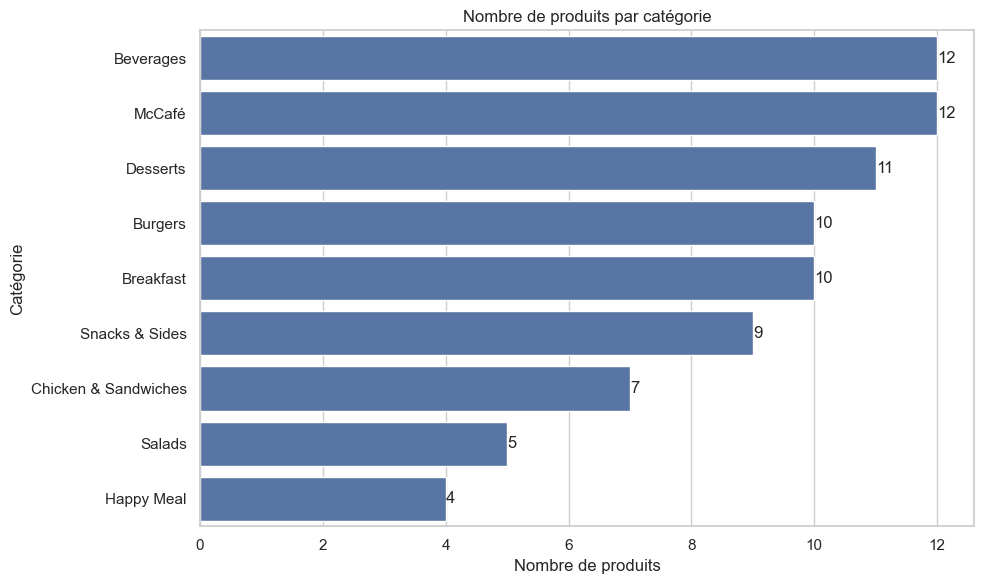

In [ ]:
# ============================================================
# 14.1 — RÉPARTITION DES PRODUITS PAR CATÉGORIE
# ============================================================

category_counts = (
    df_analysis["category"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title("Nombre de produits par catégorie")
plt.xlabel("Nombre de produits")
plt.ylabel("Catégorie")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

## 13.2 — Distribution des prix

### Question analytique

Comment les prix des produits sont-ils distribués dans le dataset ?

### Choix de la visualisation

Un **histogramme** permet d'observer la concentration des produits dans les différents intervalles de prix.

### Observation

Les prix s'étendent de **1,19 USD à 7,70 USD**. La moyenne est de **4,08 USD** et la médiane de **3,98 USD**. Une part importante des produits se situe dans une zone de prix intermédiaire.

### Interprétation

La proximité entre la moyenne et la médiane indique que la distribution globale des prix n'est pas fortement déséquilibrée. Les produits présentent néanmoins une amplitude de prix relativement large.

### Limitation

Les prix étudiés sont ceux présents dans le dataset. Ils ne doivent pas être considérés comme des prix universels de McDonald's, car ils peuvent dépendre du contexte du dataset, du marché ou du restaurant.


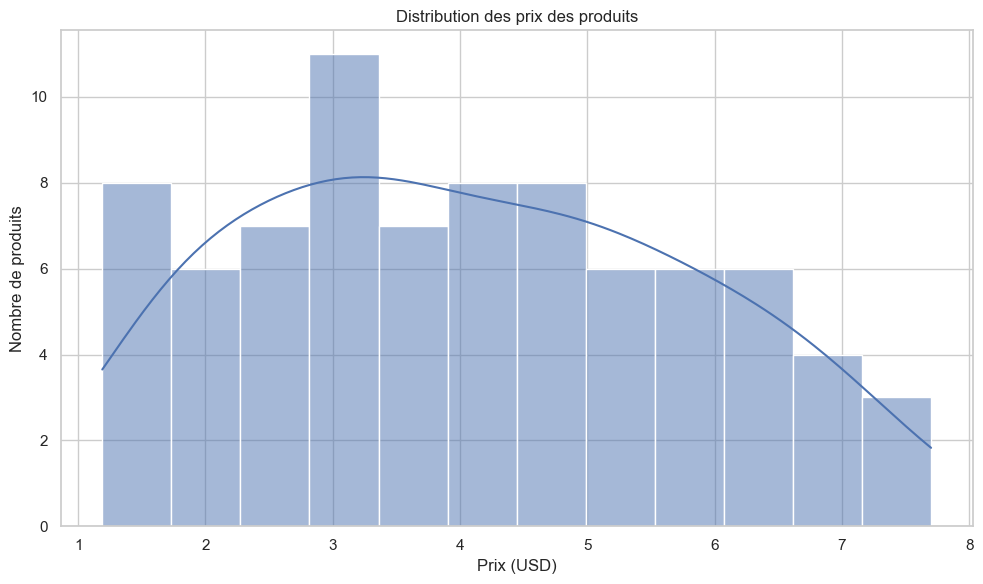

In [41]:
# ============================================================
# 14.2 — DISTRIBUTION DES PRIX
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_analysis,
    x="price_usd",
    bins=12,
    kde=True
)

plt.title("Distribution des prix des produits")
plt.xlabel("Prix (USD)")
plt.ylabel("Nombre de produits")

plt.tight_layout()
plt.show()

## 13.3 — Prix par catégorie

### Question analytique

Comment les niveaux de prix et leur dispersion varient-ils selon les catégories ?

### Choix de la visualisation

Un **boxplot** permet de comparer simultanément la médiane, la dispersion et les valeurs atypiques entre catégories.

### Observation

Les catégories `Burgers`, `Salads`, `Happy Meal` et `Chicken & Sandwiches` présentent globalement les niveaux de prix les plus élevés. À l'inverse, `Beverages`, `McCafé` et `Desserts` présentent des prix généralement plus faibles.

### Interprétation

Le niveau de prix varie donc sensiblement selon la catégorie. Cette différence semble liée à la nature des produits proposés dans chaque famille.

### Limitation

La comparaison repose sur les produits disponibles dans le dataset. Les différences de prix ne permettent pas d'évaluer une rentabilité ou une performance commerciale.


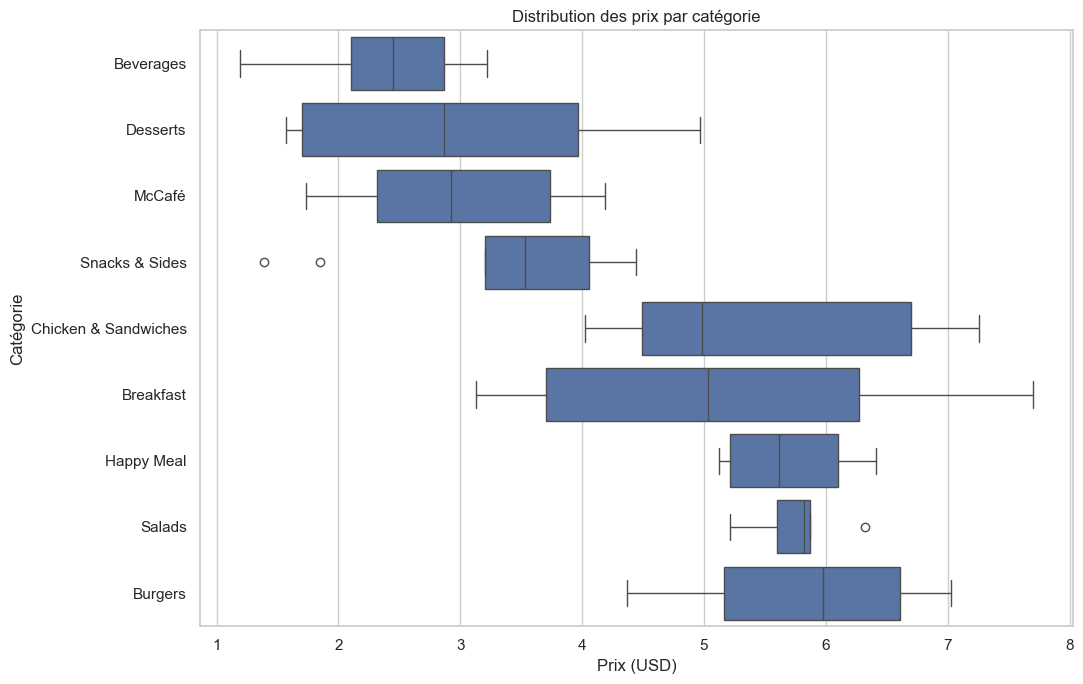

In [42]:
# ============================================================
# 13.3 — PRIX PAR CATÉGORIE
# ============================================================

price_order = (
    df_analysis.groupby("category")["price_usd"]
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(11, 7))

sns.boxplot(
    data=df_analysis,
    x="price_usd",
    y="category",
    order=price_order
)

plt.title("Distribution des prix par catégorie")
plt.xlabel("Prix (USD)")
plt.ylabel("Catégorie")

plt.tight_layout()
plt.show()

## 13.4 — Calories par catégorie

### Question analytique

Comment les niveaux caloriques diffèrent-ils selon les catégories de produits ?

### Choix de la visualisation

Un **boxplot** permet de comparer les distributions de calories entre catégories et d'identifier leur dispersion.

### Observation

Les catégories de produits solides, notamment les `Burgers`, `Chicken & Sandwiches` et `Breakfast`, présentent globalement des niveaux caloriques plus élevés. Les `Beverages` et `McCafé` présentent des niveaux généralement plus faibles.

### Interprétation

Le profil calorique varie donc fortement selon la catégorie du produit. Les différences observées montrent que la catégorie constitue une dimension importante pour comprendre la distribution des calories dans ce catalogue.

### Limitation

Cette analyse est descriptive. Elle ne permet pas de déterminer si un produit est adapté ou non à un besoin nutritionnel individuel et ne constitue pas un conseil médical.


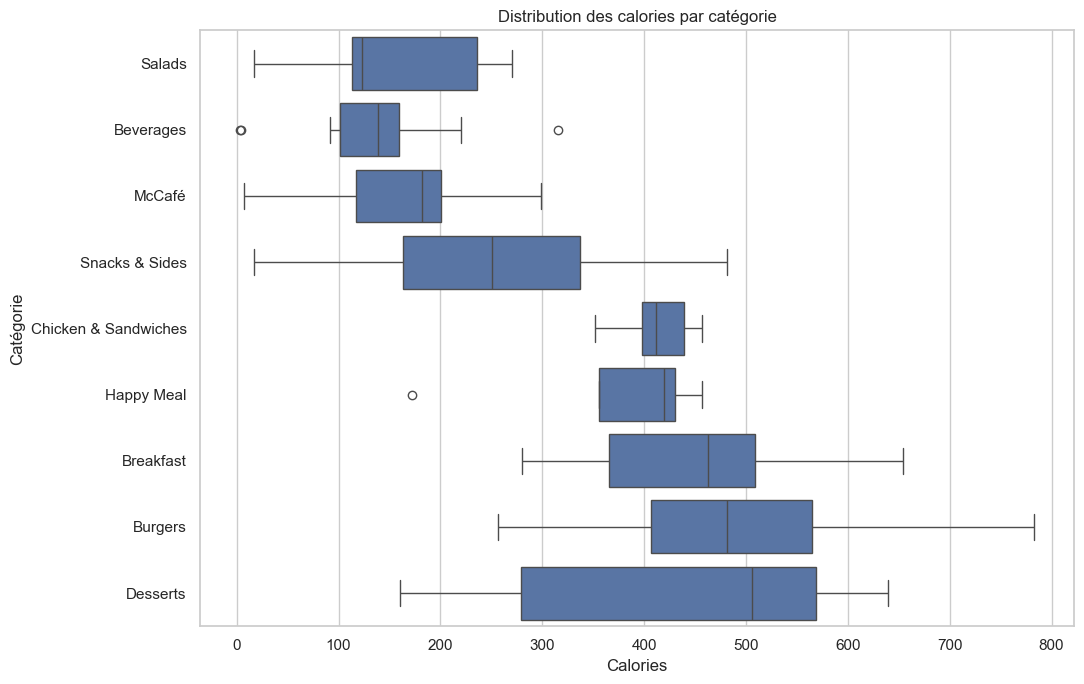

In [43]:
# ============================================================
# 13.4 — CALORIES PAR CATÉGORIE
# ============================================================

calorie_order = (
    df_analysis.groupby("category")["calories"]
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(11, 7))

sns.boxplot(
    data=df_analysis,
    x="calories",
    y="category",
    order=calorie_order
)

plt.title("Distribution des calories par catégorie")
plt.xlabel("Calories")
plt.ylabel("Catégorie")

plt.tight_layout()
plt.show()

## 13.5 — Relation entre prix et calories

### Question analytique

Existe-t-il une association entre le prix d'un produit et son nombre de calories ?

### Choix de la visualisation

Un **scatter plot** permet d'observer la relation entre deux variables numériques, chaque point représentant un produit.

### Observation

La corrélation de Pearson entre le prix et les calories est de **0,41**, tandis que la corrélation de Spearman est de **0,44**. Les deux coefficients indiquent une association positive modérée.

### Interprétation

Dans cet échantillon, les produits les plus chers ont tendance à être associés à davantage de calories. Cependant, la dispersion des points montre que le prix ne permet pas à lui seul de prédire précisément le niveau calorique.

### Limitation

Cette association ne signifie pas que le prix provoque une augmentation des calories. D'autres facteurs, notamment la catégorie et la composition du produit, peuvent intervenir. Une corrélation ne constitue pas une relation de causalité.


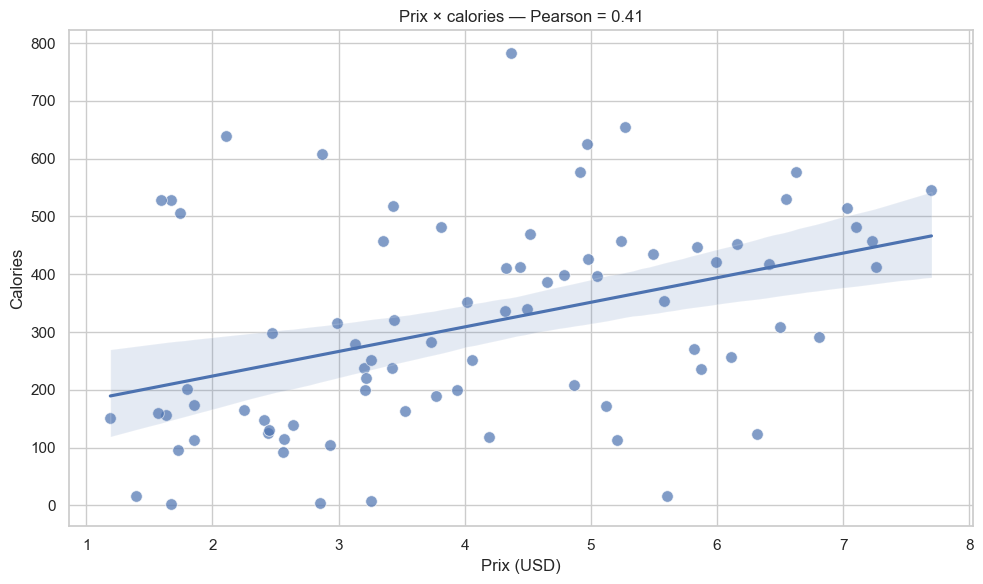

Corrélation de Pearson : 0.408
Corrélation de Spearman : 0.437


In [44]:
# ============================================================
# 13.5 — RELATION PRIX × CALORIES
# ============================================================

pair_price_calories = (
    df_analysis[["price_usd", "calories"]]
    .dropna()
)

pearson_price_calories = (
    pair_price_calories["price_usd"]
    .corr(pair_price_calories["calories"], method="pearson")
)

spearman_price_calories = (
    pair_price_calories["price_usd"]
    .corr(pair_price_calories["calories"], method="spearman")
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pair_price_calories,
    x="price_usd",
    y="calories",
    s=70,
    alpha=0.7
)

sns.regplot(
    data=pair_price_calories,
    x="price_usd",
    y="calories",
    scatter=False
)

plt.title(
    f"Prix × calories — Pearson = {pearson_price_calories:.2f}"
)

plt.xlabel("Prix (USD)")
plt.ylabel("Calories")

plt.tight_layout()
plt.show()

print(f"Corrélation de Pearson : {pearson_price_calories:.3f}")
print(f"Corrélation de Spearman : {spearman_price_calories:.3f}")

## 13.6 — Matrice de corrélation

### Question analytique

Quelles variables numériques présentent les associations linéaires les plus importantes dans le dataset ?

### Observation

Les associations les plus fortes concernent principalement les variables nutritionnelles. La corrélation entre `total_fat_g` et `saturated_fat_g` atteint **0,98**, tandis que la corrélation entre `calories` et `total_fat_g` atteint **0,90**.

Le prix présente des associations positives plus modérées avec certaines variables, notamment le sodium (**0,67**), les protéines (**0,59**) et les lipides totaux (**0,54**).

### Interprétation

Les variables nutritionnelles sont donc globalement davantage associées entre elles et aux calories que le prix ne l'est avec les variables nutritionnelles.

Certaines fortes corrélations sont toutefois en partie structurelles : par exemple, les lipides saturés constituent une composante des lipides totaux.

### Limitation

Une corrélation mesure une association statistique et non une causalité. Une corrélation proche de zéro indique également l'absence d'association linéaire importante dans cet échantillon, mais ne signifie pas nécessairement l'absence de toute relation.


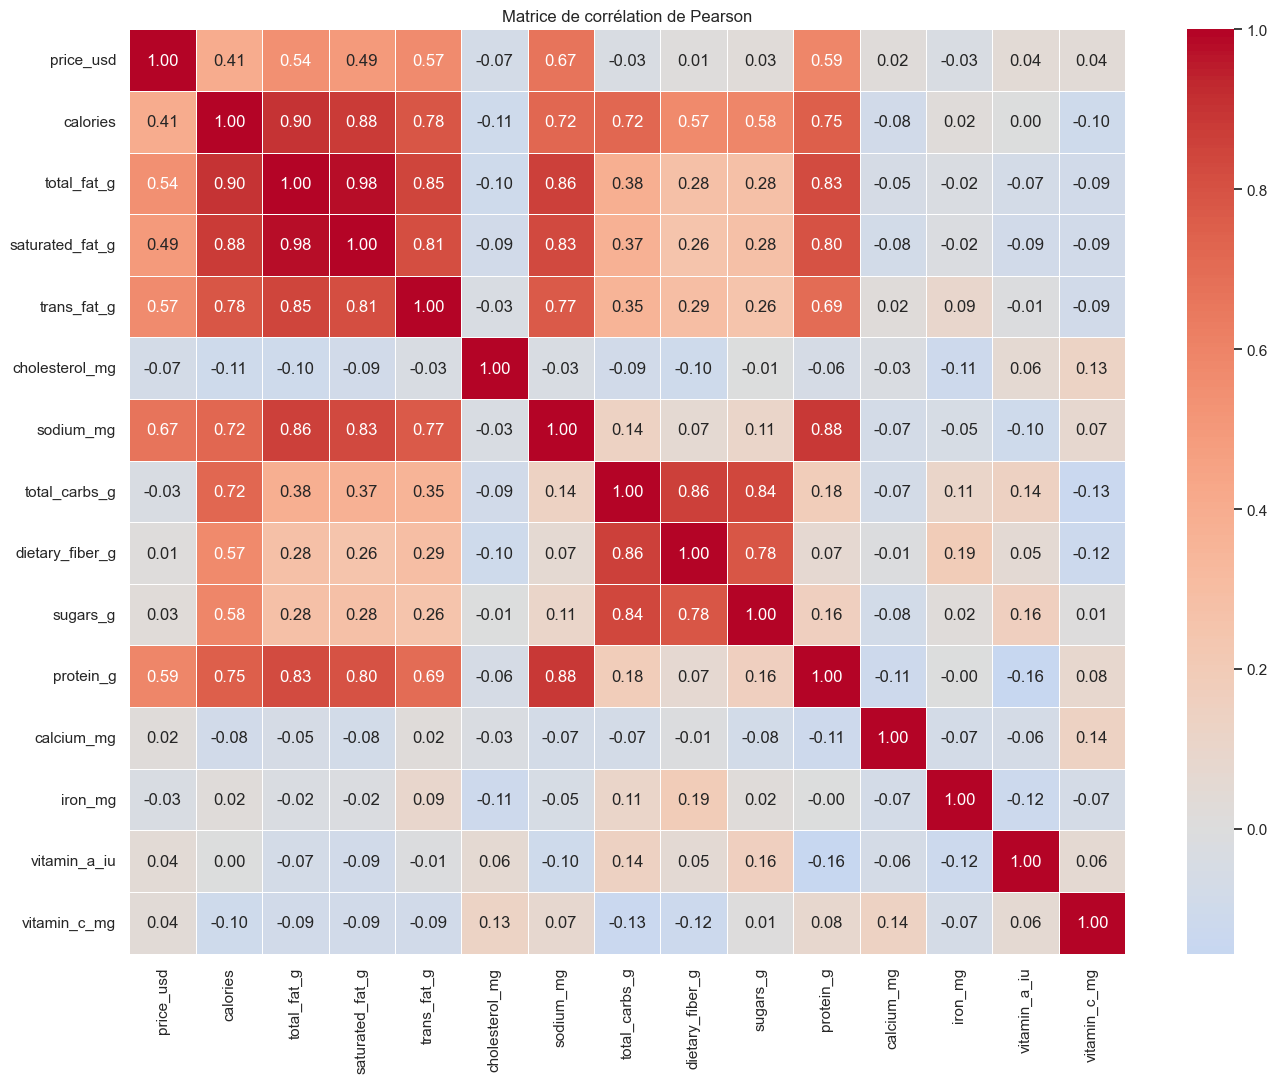

In [45]:
# ============================================================
# 13.6 — HEATMAP DES CORRÉLATIONS
# ============================================================

correlation_cols = [
    "price_usd",
    "calories",
    "total_fat_g",
    "saturated_fat_g",
    "trans_fat_g",
    "cholesterol_mg",
    "sodium_mg",
    "total_carbs_g",
    "dietary_fiber_g",
    "sugars_g",
    "protein_g",
    "calcium_mg",
    "iron_mg",
    "vitamin_a_iu",
    "vitamin_c_mg"
]

correlation_matrix = (
    df_analysis[correlation_cols]
    .corr(method="pearson")
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Matrice de corrélation de Pearson")
plt.tight_layout()
plt.show()

## 13.7 — Visualisation finale : prix médian par catégorie

### Pourquoi cette visualisation ?

Cette visualisation synthétise une différence importante observée dans l'analyse : **le niveau de prix varie selon les catégories du catalogue**.

La médiane est retenue car elle permet de représenter le niveau central des prix tout en étant moins sensible aux valeurs extrêmes que la moyenne.

### Message principal

Les catégories ne présentent pas toutes le même positionnement tarifaire. Les `Burgers`, `Salads` et `Happy Meal` figurent parmi les catégories ayant les prix médians les plus élevés, tandis que les `Beverages`, `McCafé` et `Desserts` se situent à des niveaux plus faibles.

### Limitation

Cette visualisation décrit uniquement les prix observés dans le dataset. Elle ne permet pas de mesurer les ventes, la rentabilité ou la performance commerciale réelle des catégories.


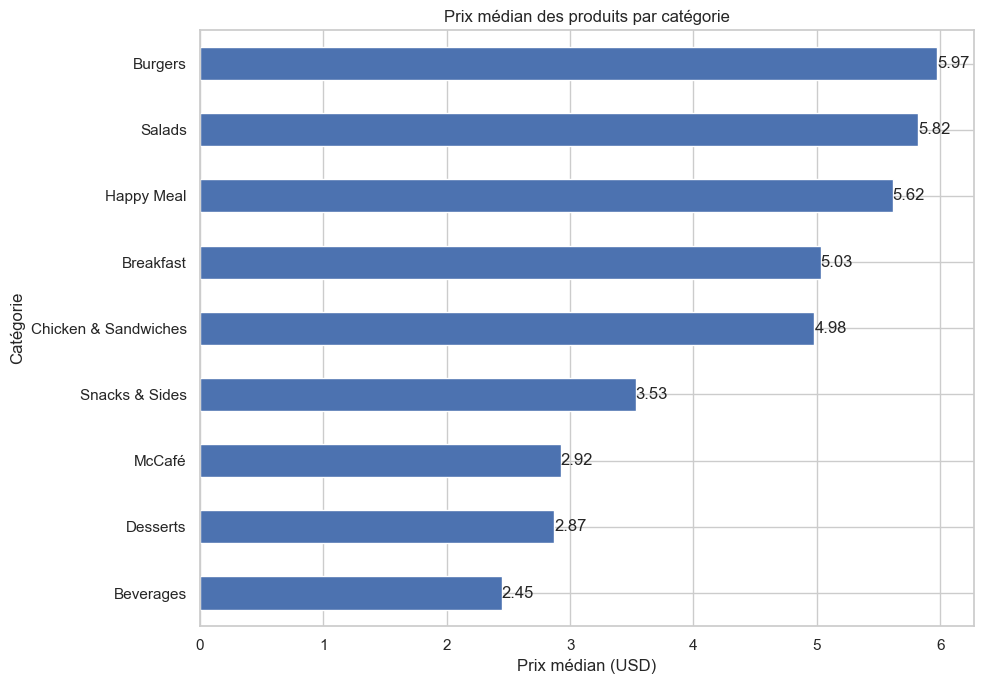

In [46]:
# ============================================================
# 13.7 — VISUALISATION FINALE
# PRIX MÉDIAN PAR CATÉGORIE
# ============================================================

median_price = (
    df_analysis
    .groupby("category")["price_usd"]
    .median()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))

ax = median_price.plot(kind="barh")

plt.title("Prix médian des produits par catégorie")
plt.xlabel("Prix médian (USD)")
plt.ylabel("Catégorie")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f"
    )

plt.tight_layout()
plt.show()

# 14. Sélection des KPI

Les KPI retenus doivent permettre de répondre rapidement aux principales questions du projet sans multiplier les statistiques.

Les indicateurs sélectionnés sont :

| KPI                         | Question analytique                                  |
| --------------------------- | ---------------------------------------------------- |
| Nombre de produits          | Quelle est la taille du catalogue étudié ?           |
| Nombre de catégories        | Quelle est la diversité du catalogue ?               |
| Prix médian                 | Quel est le niveau de prix central ?                 |
| Calories médianes           | Quel est le niveau calorique central ?               |
| Produit le plus calorique   | Quel produit présente la valeur calorique maximale ? |
| Corrélation prix × calories | Existe-t-il une association entre prix et calories ? |

Ces indicateurs sont descriptifs. Ils ne mesurent ni les ventes, ni la rentabilité, ni la satisfaction client.

Les indicateurs nutritionnels ne doivent pas non plus être interprétés comme des recommandations médicales.



In [47]:
# ============================================================
# 14 — KPI PRINCIPAUX
# ============================================================

n_products = df_analysis["item_id"].nunique()

n_categories = df_analysis["category"].nunique()

median_price = df_analysis["price_usd"].median()

median_calories = df_analysis["calories"].median()

top_calorie_product = (
    df_analysis
    .loc[
        df_analysis["calories"].idxmax(),
        ["item_name", "category", "calories", "price_usd"]
    ]
)

price_calories_corr = (
    df_analysis["price_usd"]
    .corr(df_analysis["calories"], method="pearson")
)

kpi_summary = pd.DataFrame({
    "KPI": [
        "Nombre de produits",
        "Nombre de catégories",
        "Prix médian (USD)",
        "Calories médianes",
        "Produit le plus calorique",
        "Corrélation prix × calories"
    ],
    "Valeur": [
        n_products,
        n_categories,
        round(median_price, 2),
        round(median_calories, 0),
        top_calorie_product["item_name"],
        round(price_calories_corr, 2)
    ]
})

display(kpi_summary)

,KPI,Valeur
0,Nombre de produits,80
1,Nombre de catégories,9
2,Prix médian (USD),3.98
3,Calories médianes,295.00
4,Produit le plus calorique,Double Quarter Pounder with Cheese
5,Corrélation prix × calories,0.41


In [48]:
# ============================================================
# KPI COMPLÉMENTAIRE — TOP 10 PRODUITS LES PLUS CALORIQUES
# ============================================================

top_calories = (
    df_analysis
    .nlargest(10, "calories")
    [["item_name", "category", "calories", "price_usd"]]
    .sort_values("calories")
)

display(top_calories)

,item_name,category,calories,price_usd
57,Chocolate Shake (Small),Desserts,529,1.67
0,Big Mac,Burgers,530,6.55
36,Sausage Biscuit with Egg,Breakfast,546,7.70
7,Quarter Pounder with Cheese Deluxe,Burgers,577,6.63
8,Big Mac with Bacon,Burgers,577,4.91
55,McFlurry with Chocolate Chip,Desserts,608,2.87
54,McFlurry with Oreo,Desserts,626,4.97
53,McFlurry with M&M's,Desserts,639,2.11
40,Deluxe Breakfast,Breakfast,654,5.27
9,Double Quarter Pounder with Cheese,Burgers,783,4.37


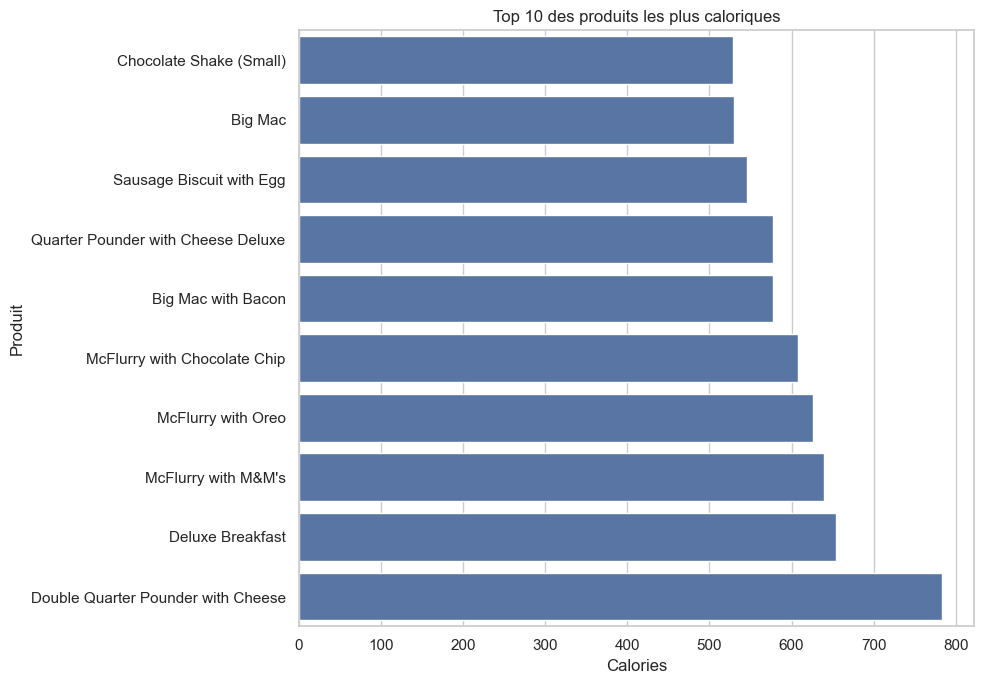

In [49]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_calories,
    x="calories",
    y="item_name"
)

plt.title("Top 10 des produits les plus caloriques")
plt.xlabel("Calories")
plt.ylabel("Produit")

plt.tight_layout()
plt.show()

# 15. Synthèse des résultats

## 15.1 — Structure du catalogue

Le dataset étudié contient **80 produits répartis dans 9 catégories**. Les catégories `Beverages` et `McCafé` sont les plus représentées avec 12 produits chacune.

Cette répartition décrit la structure du catalogue étudié, mais ne permet pas d'inférer la popularité ou le niveau de ventes des catégories.

## 15.2 — Prix

Les prix observés vont de **1,19 USD à 7,70 USD**. Le prix moyen est de **4,08 USD**, tandis que le prix médian est de **3,98 USD**.

Les niveaux de prix diffèrent selon les catégories. Les `Burgers`, `Salads`, `Happy Meal` et `Chicken & Sandwiches` présentent globalement des prix plus élevés, tandis que `Beverages`, `McCafé` et `Desserts` sont généralement moins chers.

## 15.3 — Calories et nutrition

Les caractéristiques nutritionnelles varient fortement entre les catégories.

Les analyses montrent notamment des niveaux plus élevés de lipides, protéines et sodium dans certaines catégories de produits solides, tandis que les boissons et certaines catégories du McCafé présentent généralement des valeurs plus faibles pour plusieurs variables nutritionnelles.

L'analyse descriptive ne permet cependant pas de classer les produits selon leur qualité nutritionnelle globale et ne constitue pas un conseil médical.

## 15.4 — Relations entre les variables

Une association positive modérée est observée entre le **prix et les calories** :

* Pearson : **0,41**
* Spearman : **0,44**

Une association plus forte est observée entre le **prix et les protéines** :

* Pearson : **0,59**
* Spearman : **0,63**

Les calories présentent par ailleurs de fortes associations avec plusieurs variables nutritionnelles, notamment :

* calories × lipides totaux : **0,90**
* calories × lipides saturés : **0,88**
* calories × protéines : **0,75**
* calories × sodium : **0,72**
* calories × glucides : **0,72**

La matrice de corrélation confirme également de fortes associations entre certaines variables nutritionnelles. Par exemple, `total_fat_g` et `saturated_fat_g` présentent une corrélation de **0,98**.

Ces résultats doivent être interprétés comme des associations statistiques. Ils ne permettent pas de conclure à des relations causales.

## 15.5 — Qualité des données

L'audit qualité a permis d'identifier plusieurs éléments nécessitant une attention particulière, notamment des valeurs négatives dans quatre variables nutritionnelles.

Ces valeurs ont fait l'objet d'une correction documentée par valeur absolue dans le DataFrame d'analyse, tandis que les données originales sont conservées dans `df_raw` afin de garantir la traçabilité.

Les valeurs atypiques identifiées par la méthode de l'IQR n'ont pas été supprimées automatiquement. Une valeur atypique n'est pas nécessairement une erreur.

## 15.6 — Réponse à la problématique

Les données montrent donc que **le prix, les calories et les caractéristiques nutritionnelles présentent des différences et des associations mesurables dans le catalogue étudié**.

Le prix varie selon les catégories et présente une association positive modérée avec les calories et plus marquée avec les protéines. Les variables nutritionnelles présentent quant à elles des associations souvent beaucoup plus fortes entre elles et avec les calories.

Cependant, ces résultats restent **descriptifs** : le dataset ne contient pas d'informations de ventes, de fréquentation, de préférences clients ou de contexte commercial permettant d'aller jusqu'à une analyse de performance ou de causalité.


# 16. Limites du dataset et du périmètre

L'analyse présente plusieurs limites qu'il est nécessaire de prendre en compte avant toute généralisation des résultats.

### 16.1 — Un catalogue et non des données transactionnelles

Le dataset décrit des produits du menu, mais ne contient pas de données de ventes, de quantités vendues, de chiffre d'affaires ou de fréquentation.

Il n'est donc pas possible d'identifier les produits les plus vendus ou les catégories les plus performantes commercialement.

### 16.2 — Périmètre des prix

Les prix analysés correspondent aux valeurs présentes dans le dataset.

Ils ne doivent pas être considérés comme des prix universels de McDonald's, car les prix peuvent varier selon le contexte couvert par la source.

### 16.3 — Taille du dataset

L'analyse porte sur **80 produits et 9 catégories**. Certaines catégories contiennent peu d'observations, ce qui limite la robustesse de certaines comparaisons statistiques.

### 16.4 — Données nutritionnelles

Les variables nutritionnelles sont analysées de manière descriptive. Elles ne permettent pas de produire une recommandation nutritionnelle individuelle ou médicale.

### 16.5 — Valeurs atypiques

Les observations atypiques identifiées ne sont pas automatiquement considérées comme des erreurs. Elles peuvent correspondre à des produits réellement différents des autres.

### 16.6 — Corrections de nettoyage

Certaines valeurs négatives ont été corrigées dans quatre variables nutritionnelles à l'aide de la valeur absolue.

Cette règle constitue une **décision de nettoyage documentée** fondée sur l'audit. Elle ne signifie pas que nous avons modifié la source brute : les valeurs originales restent disponibles dans `df_raw`.

### 16.7 — Corrélation et causalité

Les coefficients de corrélation décrivent des associations entre variables dans cet échantillon.

Ils ne permettent pas d'affirmer qu'une variable provoque une modification d'une autre.

### 16.8 — Variables dérivées

Les indicateurs tels que `price_per_1000_kcal`, `calories_per_dollar` et `protein_per_dollar` sont des indicateurs descriptifs construits pour répondre à certaines questions analytiques.

Ils ne représentent pas une rentabilité, une valeur commerciale réelle ou une recommandation nutritionnelle.

### 16.9 — Portée des conclusions

Les conclusions doivent donc être limitées au périmètre du dataset étudié. Elles permettent de comprendre la structure, les prix, les calories et les associations nutritionnelles observées dans cet échantillon, mais ne permettent pas de généraliser les résultats à l'ensemble de l'activité McDonald's.


# 17. Conclusion finale

Cette analyse exploratoire du dataset **McDonald's Menu 2026** avait pour objectif de comprendre la structure du catalogue et d'étudier les relations entre les prix, les calories et les caractéristiques nutritionnelles des produits.

L'analyse a d'abord permis de contrôler la qualité des données, d'identifier les anomalies et de documenter les décisions de nettoyage. Cette étape a permis de construire un DataFrame d'analyse tout en conservant les données originales pour assurer la traçabilité.

L'exploration montre que le catalogue étudié contient **80 produits répartis dans 9 catégories**, avec des différences importantes de prix et de caractéristiques nutritionnelles entre les familles de produits.

Les prix s'étendent de **1,19 USD à 7,70 USD**, tandis que les relations étudiées montrent une association positive modérée entre le prix et les calories (**Pearson = 0,41**). L'association entre prix et protéines est plus importante (**Pearson = 0,59**).

L'analyse des corrélations montre surtout que les variables nutritionnelles sont fortement liées entre elles et aux calories. Par exemple, la corrélation entre les lipides totaux et les lipides saturés atteint **0,98**, et celle entre les calories et les lipides totaux atteint **0,90**.

Ces résultats permettent donc de répondre à la problématique : **dans le catalogue étudié, les prix, les calories et les caractéristiques nutritionnelles présentent des différences entre catégories et plusieurs associations statistiques importantes**.

Cependant, le dataset reste un **catalogue de produits** et non une base transactionnelle. Il ne permet donc pas de conclure sur les ventes, la rentabilité, les préférences des consommateurs ou la causalité entre les variables.

La principale conclusion méthodologique est ainsi la suivante :

> **Les données permettent de décrire et de comparer les produits du catalogue, mais les conclusions doivent rester descriptives et être interprétées dans les limites du périmètre et de la qualité du dataset.**

